# 🔥 **Cezayir Orman Yangınları - Regresyon Analizi**

## **GİRİŞ: Bu Derste Ne Yapıyoruz?**

Hoş geldiniz! Bugün sizler, **gerçek hayattan gelen bir veri seti** üzerinde makine öğrenmesinin tüm aşamalarını adım adım öğreneceksiniz. Elimizdeki veri set **Cezayir Orman Yangınları (Algerian Forest Fires)** ve bu, sadece bir "örnek veri" değil—**iş dünyasında karşılaşacağınız gerçek sorunları** simüle ediyor.

### **Neden bu veri seti özel?**
✓ **Ham ve "kirli" bir veri seti** → Eksik değerler, yanlış satırlar, boşluklu sütun adları  
✓ **Çoklu bölge verisi** → Gerçek hayatta "şube bazlı" veri yönetimini simüle ediyor  
✓ **İndeks dünyas**ı → İş yaşamında "skoru" nasıl kullandığını gösterir  
✓ **Regresyon hedefi (FWI)** → Sayısal tahminler, kararlar, optimizasyon  

### **Bugünün Hedefi**
Regresyon modeli kurmak, yani:  
> **Bir günün hava durumu ve orman özelliklerine bakarak, yangın risk endeksini (FWI) tahmin etmek**

Bu, YBS açısından şu iş problemlerine benzer:
- Müşteri satın alma olasılığını tahmin etme
- Stok zaman serilerini öngörme
- Makine arızaya kaç gün kaldığını hesaplama
- Ürün fiyatını maliyete göre belirlemek

---

### **Ders Akışı: 12 Adım**
| Adım | Başlık | Amaç |
|------|--------|------|
| 1️⃣ | **Veri Yükleme & İlk Tanı** | Veri setinin şeklini, boyutunu, sorunlarını görmek |
| 2️⃣ | Sütunları Anlama | Her sütunun anlamını, endüstri bağlamını kurmak |
| 3️⃣ | Ham Verideki Sorunları Teşhis | Boş satırlar, yanlış veriler, kesintiler |
| 4️⃣ | Bölge (Region) Ekleme | Veri mühendisliği başlangıcı |
| 5️⃣ | Sütun Adlarını Temizleme | Boşlukları kaldırma, veri sözleşmesi |
| 6️⃣ | Veri Tiplerini Düzeltme | Object → int/float dönüşümleri |
| 7️⃣ | Classes Sütununu Temizleme | Metin normalizasyonu |
| 8️⃣ | Hedef Değişken Seçimi | Regression mi, Classification mi? |
| 9️⃣ | Keşifsel Analiz (EDA) | Korelasyon, dağılımlar, anomaliler |
| 🔟 | Multicollinearity Analizi | Redundant değişkenleri tespit etme |
| 1️⃣1️⃣ | Train-Test & Scaling | Bölme, ölçeklendirme, hazırlık |
| 1️⃣2️⃣ | Modelleme & Karşılaştırma | Linear, Ridge, Lasso, Elastic Net, LazyPredict |

### **Öncelikle Bilmeniz Gerekenler**
- 🎓 Bu ders **YBS Sistemi ve Iş Bilimleri** perspektifinden tasarlanmış
- 📊 Her adımda gerçek iş ortamındaki karşılıkları göreceksiniz
- 💡 **Kod yazabilmek** kadar önemli: **veriyi anlamak, soruyu doğru kurmak, modeli yorumlamak**
- ⚠️ Hiçbir model "sihirli değildir"—her modelin varsayımları, kısıtları, doğru ayarlanışı vardır

**Hadi başlayalım!** 🚀

# **ADIM 1: Veri Setini Yükleme ve İlk Tanı**

## **1.1 Gerekli Kütüphaneleri İmport Ediyoruz**

In [2]:
# Veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistiksel işlemler
from scipy import stats

# Model ve değerlendirme
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Uyarıları azaltmak için
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Tüm kütüphaneler başarıyla yüklendi!")

✓ Tüm kütüphaneler başarıyla yüklendi!


## **1.2 Veri Setini Yüklüyoruz**

In [4]:
# Veri setini yükle
df_ham = pd.read_csv('Algerian_forest_fires_dataset.csv')

# Veri setinin boyutlarını görelim
print("═" * 70)
print("VERİ SETİNİN TEMEL BİLGİLERİ")
print("═" * 70)
print(f"\n📊 Veri Seti Boyutu: {df_ham.shape[0]} satır × {df_ham.shape[1]} sütun")
print(f"\n💾 Bellek Kullanımı: {df_ham.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\n📋 Sütun Adları:\n{list(df_ham.columns)}")
print(f"\n🔍 Veri Tipları:\n{df_ham.dtypes}")

══════════════════════════════════════════════════════════════════════
VERİ SETİNİN TEMEL BİLGİLERİ
══════════════════════════════════════════════════════════════════════

📊 Veri Seti Boyutu: 247 satır × 14 sütun

💾 Bellek Kullanımı: 175.55 KB

📋 Sütun Adları:
['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ']

🔍 Veri Tipları:
day            object
month          object
year           object
Temperature    object
 RH            object
 Ws            object
Rain           object
FFMC           object
DMC            object
DC             object
ISI            object
BUI            object
FWI            object
Classes        object
dtype: object


## **1.3 İlk 10 Satırı İnceliyoruz**

In [3]:
# İlk 10 satırı görelim
print("\n" + "═" * 70)
print("İLK 10 SATIR (HAM VERİ)")
print("═" * 70)
pd.options.display.max_columns = None
print(df_ham.head(10).to_string())


══════════════════════════════════════════════════════════════════════
İLK 10 SATIR (HAM VERİ)
══════════════════════════════════════════════════════════════════════
  day month  year Temperature  RH  Ws Rain   FFMC   DMC    DC  ISI   BUI  FWI    Classes  
0   1     6  2012          29  57  18     0  65.7   3.4   7.6  1.3   3.4  0.5  not fire   
1   2     6  2012          29  61  13   1.3  64.4   4.1   7.6    1   3.9  0.4  not fire   
2   3     6  2012          26  82  22  13.1  47.1   2.5   7.1  0.3   2.7  0.1  not fire   
3   4     6  2012          25  89  13   2.5  28.6   1.3   6.9    0   1.7    0  not fire   
4   5     6  2012          27  77  16     0  64.8     3  14.2  1.2   3.9  0.5  not fire   
5   6     6  2012          31  67  14     0  82.6   5.8  22.2  3.1     7  2.5      fire   
6   7     6  2012          33  54  13     0  88.2   9.9  30.5  6.4  10.9  7.2      fire   
7   8     6  2012          30  73  15     0  86.6  12.1  38.3  5.6  13.5  7.1      fire   
8   9     6  2

## **1.4 Eksik Değerleri Teşhis Ediyoruz**

In [3]:
# Eksik değer analizi
print("\n" + "═" * 70)
print("EKSIK DEĞER ANALİZİ")
print("═" * 70)

# Her sütundaki eksik değerler
eksik_sayı = df_ham.isnull().sum()
eksik_yuzde = (df_ham.isnull().sum() / len(df_ham)) * 100

eksik_df = pd.DataFrame({
    'Sütun Adı': df_ham.columns,
    'Eksik Sayı': eksik_sayı.values,
    'Eksik Yüzde (%)': eksik_yuzde.values
})

print(eksik_df.to_string(index=False))
print(f"\n⚠️ TOPLAM EKSİK HÜCRE: {df_ham.isnull().sum().sum()}")
print(f"⚠️ TOPLAM DOLU HÜCRE: {df_ham.notnull().sum().sum()}")


══════════════════════════════════════════════════════════════════════
EKSIK DEĞER ANALİZİ
══════════════════════════════════════════════════════════════════════


NameError: name 'df_ham' is not defined

## **1.5 Ham Verinin Sorunlu Satırlarını Buluyoruz**

In [9]:
# Tamamen boş satırları bul
print("\n" + "═" * 70)
print("SORUNLU SATIRLARI TESPİT EDİYORUZ")
print("═" * 70)

# Satır bazında eksik değer sayısı
satir_eksik = df_ham.isnull().sum(axis=1)
tamamen_bos_satirlar = satir_eksik[satir_eksik == len(df_ham.columns)].index.tolist()
kismen_bos_satirlar = satir_eksik[(satir_eksik > 0) & (satir_eksik < len(df_ham.columns))].index.tolist()

print(f"\n🔴 TAMAMEN BOŞ SATIRLAR: {len(tamamen_bos_satirlar)} adet")
if tamamen_bos_satirlar:
    print(f"   Satır indexleri: {tamamen_bos_satirlar}")

print(f"\n🟠 KISMİ OLARAK BOŞ SATIRLAR: {len(kismen_bos_satirlar)} adet")
if kismen_bos_satirlar:
    print(f"   Satır indexleri (ilk 10): {kismen_bos_satirlar[:10]}")

# Bu satırları görelim
if kismen_bos_satirlar:
    print("\n📋 SORUNLU SATIRLARIN DETAYI (ilk 10):")
    print(df_ham.iloc[kismen_bos_satirlar[:10]].to_string())


══════════════════════════════════════════════════════════════════════
SORUNLU SATIRLARI TESPİT EDİYORUZ
══════════════════════════════════════════════════════════════════════

🔴 TAMAMEN BOŞ SATIRLAR: 1 adet
   Satır indexleri: [122]

🟠 KISMİ OLARAK BOŞ SATIRLAR: 2 adet
   Satır indexleri (ilk 10): [123, 168]

📋 SORUNLU SATIRLARIN DETAYI (ilk 10):
                               day month  year Temperature   RH   Ws Rain   FFMC   DMC      DC   ISI   BUI      FWI Classes  
123  Sidi-Bel Abbes Region Dataset   NaN   NaN         NaN  NaN  NaN   NaN   NaN   NaN     NaN   NaN   NaN      NaN       NaN
168                             14     7  2012          37   37   18   0.2  88.9  12.9  14.6 9  12.5  10.4  fire          NaN


## **1.6 Veri Setinin Yapısını Görselleştiriyoruz (Mermaid Diagram)**

Aşağıdaki diyagram, veri yolculuğumuzun nereden başladığını gösteriyor:

```mermaid
graph TD
    A["CSVDosya: Cezayir Orman Yangınları
    247 satır × 14 sütun"] 
    B["Ham Veri
    Sorunlar:
    • Boş satırlar
    • Başlık satırı karışık
    • Bölge etiketi satırları
    • Sütun adında boşluklar
    • Object tipinde sayılar"]
    C["Veri Temizliği
    • Sorunlu satırları çıkar
    • Region ekle
    • Sütun adlarını normalize et
    • Tipleri dönüştür"]
    D["Temiz Veri
    ~242-243 satır
    Tüm değişkenler doğru tip
    Korelasyon analizi hazır"]
    E["İleri Analiz
    • EDA
    • Feature Selection
    • Modeling"]
    F["Regresyon Modeli
    FWI = f(Sıcaklık, Nem, Rüzgar...)
    R² &gt; 0.85 hedeflemek"]
    
    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    
    style A fill:#ffd9b3,stroke:#ff9800,color:#000
    style B fill:#ffcccc,stroke:#f44336,color:#000
    style C fill:#fff9c4,stroke:#fbc02d,color:#000
    style D fill:#c8e6c9,stroke:#4caf50,color:#000
    style E fill:#bbdefb,stroke:#2196f3,color:#000
    style F fill:#e1bee7,stroke:#9c27b0,color:#000
```

## **1.7 İstatistiksel Özet (describe())**

In [6]:
# Sayısal sütunlar için özet istatistikler
print("\n" + "═" * 70)
print("SAYISAL SÜTUNLAR İÇİN TEMEL İSTATİSTİKLER")
print("═" * 70)

# Sadece sayısal sütunlar için
numeric_df = df_ham.select_dtypes(include=[np.number])

if not numeric_df.empty:
    print(numeric_df.describe().round(2))
else:
    print("⚠️ Henüz sayısal sütun bulunmuyor (veri tipinde sorun var)")
    print("\nBunun sebebi: Ham dosyada boş satırlar ve metin karışmış durumda.")
    print("Sonraki adımlarda bu sorunu çözeceğiz!")


══════════════════════════════════════════════════════════════════════
SAYISAL SÜTUNLAR İÇİN TEMEL İSTATİSTİKLER
══════════════════════════════════════════════════════════════════════
⚠️ Henüz sayısal sütun bulunmuyor (veri tipinde sorun var)

Bunun sebebi: Ham dosyada boş satırlar ve metin karışmış durumda.
Sonraki adımlarda bu sorunu çözeceğiz!


# **ADIM 2: Sütunları Anlama ve Veri Sözlüğü Oluşturma**

## **2.1 Sütunları Kategorileştiriyoruz**

Bir veri setini açtığınızda **ilk işiniz sütun adlarını okumak ve anlam yapmak**tır. Biz bu 14 sütunu üç gruba ayırabiliriz:

### **Grup 1: Takvim Bilgisi (Zamansal Veriler)**
- **day**: Ayın kaçıncı günü (1–31)
- **month**: Hangi ay (karaktersel veya numerik olabilir)
- **year**: Hangi yıl (2012 vb.)

**YBS Karşılığı**: E-ticaret veritabanında sipariş tarihi, CRM'de müşteri kayıt tarihi gibi. Bu alanlar zamansal örüntü analizi için kullanılır.

### **Grup 2: Hava Durumu Özellikleri (Meteorolojik Veriler)**
- **Temperature**: Sıcaklık (Celsius derece)
- **RH**: Relative Humidity (Bağıl Nem, %0–100)
- **Ws**: Wind Speed (Rüzgar Hızı, km/h)
- **Rain**: Yağış (mm)

**YBS Karşılığı**: Tarım veri analitiği, enerji talebi tahmini, turizm riski değerlendirmesi gibi alanlarda hava durumu önemli bir öngörücüdür.


### **Grup 3: Yangın İndeksleri (Bileşik Risk Göstergeleri)**
- **FFMC**: Fine Fuel Moisture Code (ince yakıt nem kodu)
- **DMC**: Duff Moisture Code (orta yakıt nem kodu)
- **DC**: Drought Code (kuraklık kodu)
- **ISI**: Initial Spread Index (başlangıç yayılma endeksi)
- **BUI**: Build-up Index (birikinti endeksi)
- **FWI**: Fire Weather Index (yangın hava endeksi – HEDEF DEĞİŞKEN)

**Bunlar ne anlama geliyor?** Her biri yangın dinamiğinin farklı yönünü ölçer:
- **FFMC, DMC, DC** → Yakıt nemlilik seviyelerini gösterir
- **ISI** → Yangın başladığında yayılma hızı
- **BUI** → Toplam yanabilen yakıt
- **FWI** → Tüm bu faktörlerin **birleşik risk skoru**

**YBS Karşılığı**: Kredi puanınız (gelir, borçlar, kimlik bilgileri) birleştirilip tek "skor" olur, tıpkı FWI gibi.

### **Grup 4: Sınıflandırma Hedefi**
- **Classes**: "fire" (yangın oldu) veya "not fire" (yangın olmadı)

**YBS Karşılığı**: Müşteri churn tahmininde "churn Yes/No" gibi.

## **2.2 Tablo: Sütunların Detaylı Açıklaması**

| Sütun | Anlamı | Veri Tipi | Min-Max | YBS Örneği |
|-------|--------|-----------|---------|-----------|
| **day** | Ayın günü | int | 1–31 | Sipariş günü |
| **month** | Ay numarası/adı | string/int | 1–12 veya Jan–Dec | İşlem ayı |
| **year** | Yıl | int | 2012 | Dönem yılı |
| **Temperature** | Hava sıcaklığı (°C) | float | ~7–40 | Depo sıcaklığı |
| **RH** | Bağıl nemlillik (%) | float | ~15–100 | Depo nem oranı |
| **Ws** | Rüzgar hızı (km/h) | float | ~0–40 | Lojistik gecikmesi etkeni |
| **Rain** | Yağış miktarı (mm) | float | 0–83 | Sesonluk talep faktörü |
| **FFMC** | İnce yakıt nem endeksi | float | ~0–100 | **Hızlı risk indikatörü** |
| **DMC** | Orta yakıt nem endeksi | float | ~0–220 | **Orta vadeli risk** |
| **DC** | Kuraklık endeksi | float | ~7–860 | **Uzun vadeli risk** |
| **ISI** | Yayılma hızı endeksi | float | ~0–60 | **Aciliyet göstergesi** |
| **BUI** | Birikinti endeksi | float | ~1–700 | **Toplam yanabilen kaynak** |
| **FWI** | **Yangın hava endeksi** | float | ~0–80+ | **Regresyon Hedefi: Tahmin Etmek İstediğimiz Değer** |
| **Classes** | Yangın oluş durumu | string | "fire"/"not fire" | Sınıflandırma Hedefi |

## **2.3 Neden Koğu Sütunu İlk Bakışta Bilmeyebiliriz?**

"FFMC" diye bir sütun adı görenince, kimse doğrudan anlamaz. **Bunu bilmek çerçevelemek için:**

✅ **Veri setini gönderen kuruma sarsılırız**: "Bu FFMC tam olarak neyi ölçüyor, hangi aralıkta, nasıl hesaplanıyor?"  
✅ **İnternette araştırırız**: Yangın Hava İndeksi Sistemi (FWI System) ilgili akademik makaleler veya meteoroloji standardu belgeler  
✅ **Domain expert'e sorarız**: Orman mühendisi, yangın teşkilatı uzmanı vb.

YBS'de **veri okuryazarlığının** temel bir parçası budur: "Seni yönlendiremeyeceğim, ama nereden bulacağını öğreteceğim."

## **2.4 İş Perspektifinden Hangi Sütun Neden Önemli?**

Yöneticiye "FWI değeri 0.5 mü 50 mi?" sorusunu soramaz—bunun **operasyonal anlamını** bilmek gerekir. Yangın literatüründe:

- **FWI < 10**: Düşük risk (rahatça çalışılabilir)
- **FWI 10–20**: Artan risk (dikkat gerekli)
- **FWI 20–40**: Yüksek risk (ekip hazır olsun)
- **FWI > 40**: Çok yüksek risk (acil müdahale)

İşte biz bu derste, sayıları bu **operasyonal dilden** çıkarıp model oluşturacağız: "Hava durumu şu olunca, FWI tahmini bu kadar olur."


## **2.5 Verinin Yapısını Görselleştiriyoruz (Mermaid Diyagram)**

Sütunların nasıl organize olduğunu aşağıda göreceğiz:

```mermaid
graph LR
    A["BAĞIMSIZ DEĞİŞKENLER\n(Features)"]
    
    A1["Zamansal Veriler\nday, month, year"]
    A2["Hava Durumu\nTemperature, RH\nWs, Rain"]
    A3["Yangın İndeksleri\nFFMC, DMC, DC\nISI, BUI"]
    
    B["VERİ İŞLEME\n(Feature Engineering)"]
    
    C["MODEL EĞİTİMİ\n(Regression)"]
    
    D["HEDEF DEĞİŞKEN\n(Target)\n\nFWI Tahmini"]
    
    A --> A1
    A --> A2
    A --> A3
    
    A1 --> B
    A2 --> B
    A3 --> B
    
    B --> C
    
    C --> D
    
    D2["Alternatif Hedef\n(İkinci Seçenek)\nClasses\nfire/not fire\nSınıflandırma"]
    
    A --> D2
    
    style A fill:#fff9c4,stroke:#fbc02d,color:#000
    style A1 fill:#bbdefb,stroke:#2196f3,color:#000
    style A2 fill:#c8e6c9,stroke:#4caf50,color:#000
    style A3 fill:#f8bbd0,stroke:#e91e63,color:#000
    style B fill:#ffe0b2,stroke:#ff9800,color:#000
    style C fill:#e1bee7,stroke:#9c27b0,color:#000
    style D fill:#ffcccc,stroke:#f44336,color:#000
    style D2 fill:#ffcccc,stroke:#f44336,color:#000
```

---

## **2.6 Sütunların Benzersiz Değerlerini Kontrol Ediyoruz**

In [5]:
# Takvim sütunlarının benzersiz değerlerini kontrol et
print("=" * 70)
print("TAKVIM SÜTUNLARININ BENZERSIZ DEĞERLERİ")
print("=" * 70)

print(f"\n📅 DAY (Gün) benzersiz değerleri: {sorted(df_ham['day'].dropna().unique()[:20])}")
print(f"   Toplam benzersiz: {df_ham['day'].nunique()}")

print(f"\n📅 MONTH (Ay) benzersiz değerleri: {sorted(df_ham['month'].dropna().unique())}")
print(f"   Toplam benzersiz: {df_ham['month'].nunique()}")

print(f"\n📅 YEAR (Yıl) benzersiz değerleri: {sorted(df_ham['year'].dropna().unique())}")
print(f"   Toplam benzersiz: {df_ham['year'].nunique()}")

# Ay dağılımını görelim (yangın mevsimselliği)
print("\n" + "=" * 70)
print("AY BAZINDA SATIR SAYISI (Mevsimsellik Analizi)")
print("=" * 70)

ay_sayim = df_ham['month'].value_counts().sort_index()
print(ay_sayim)

TAKVIM SÜTUNLARININ BENZERSIZ DEĞERLERİ

📅 DAY (Gün) benzersiz değerleri: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
   Toplam benzersiz: 33

📅 MONTH (Ay) benzersiz değerleri: ['6', '7', '8', '9', 'month']
   Toplam benzersiz: 5

📅 YEAR (Yıl) benzersiz değerleri: ['2012', 'year']
   Toplam benzersiz: 2

AY BAZINDA SATIR SAYISI (Mevsimsellik Analizi)
month
6        60
7        62
8        62
9        60
month     1
Name: count, dtype: int64


---

## **2.7 Hava Durumu Özelliklerinin Genel Dağılımı**

In [6]:
# Hava durumu sütunlarının tipini ve örnek değerlerini kontrol et
print("=" * 70)
print("HAVA DURUMU ÖZELLİKLERİ - ÖRNEK DEĞERLER VE İSTATİSTİKLER")
print("=" * 70)

hava_sutunlari = ['Temperature', ' RH', ' Ws', 'Rain ']

for sutun in hava_sutunlari:
    # Boşlukları düzeltme (şimdilik sadece görüntülemek için)
    sutun_temiz = sutun.strip()
    
    print(f"\n📊 {sutun_temiz}:")
    print(f"   Veri Tipi: {df_ham[sutun].dtype}")
    print(f"   Örnek Değerler (ilk 5): {df_ham[sutun].head().tolist()}")
    print(f"   Benzersiz Sayı: {df_ham[sutun].nunique()}")
    
    # Metin değerleri kontrol et
    metin_degerleri = df_ham[sutun][df_ham[sutun].notna()].astype(str)
    sayisal_olmayan = metin_degerleri[~metin_degerleri.str.replace('.', '', 1).str.isdigit()].unique()
    
    if len(sayisal_olmayan) > 0:
        print(f"   ⚠️ SAYISAL OLMAYAN DEĞERLER: {sayisal_olmayan[:5]}")
    else:
        print(f"   ✓ Tüm değerler sayısal görünüyor (henüz object tipinde)")

HAVA DURUMU ÖZELLİKLERİ - ÖRNEK DEĞERLER VE İSTATİSTİKLER

📊 Temperature:
   Veri Tipi: object
   Örnek Değerler (ilk 5): ['29', '29', '26', '25', '27']
   Benzersiz Sayı: 20
   ⚠️ SAYISAL OLMAYAN DEĞERLER: ['Temperature']

📊 RH:
   Veri Tipi: object
   Örnek Değerler (ilk 5): ['57', '61', '82', '89', '77']
   Benzersiz Sayı: 63
   ⚠️ SAYISAL OLMAYAN DEĞERLER: [' RH']

📊 Ws:
   Veri Tipi: object
   Örnek Değerler (ilk 5): ['18', '13', '22', '13', '16']
   Benzersiz Sayı: 19
   ⚠️ SAYISAL OLMAYAN DEĞERLER: [' Ws']

📊 Rain:
   Veri Tipi: object
   Örnek Değerler (ilk 5): ['0', '1.3', '13.1', '2.5', '0']
   Benzersiz Sayı: 40
   ⚠️ SAYISAL OLMAYAN DEĞERLER: ['Rain ']


## **2.8 Yangın İndeksleri Hakkında Derinlemesine Bilgi**

Yangın risk endeksleri, Kanada tarafından geliştirilen **FWI (Fire Weather Index) Sistemi**nin parçasıdır. Her indeks, yangının başlaması, yayılması ve yoğunlaşmasını etkileyen farklı bir faktörü temsil eder.

### **İndeks Hiyerarşisi**

```
FFMC (En yüzeysel, hızlı değişen)
  ↓
DMC (Orta tabaka)
  ↓
DC (Derin tabaka, yavaş değişen)
  ↓
BUI (Tüm yakıtın birleşik göstergesi)
  ↓
ISI + BUI → FWI (Nihai risk skoru)
```

### **Pratik Örnek: Bir Orman Yangını Senaryosu**

Sabah 6:00'da ormanda küçük yangın çıkıyor. Dün gece yağmur yağmış (FFMC düşük), ama derin humus tabakası kuru (DC yüksek).

- **FFMC = 35**: Yapraklar nemli, zor yanıyorlar
- **DMC = 80**: Orta tabaka kuru, hızlı yakılıyor
- **DC = 350**: Derin tabaka ÇOOK kuru, yangın saatler sürecek
- **BUI = 200**: Toplam yanabilen kaynak çok yüksek
- **ISI = 15**: Rüzgar ve sıcaklık ılımlı, hızlı yayılmaz
- **FWI = 38**: **UYARI!** Yangın kontrol altına almak zor olacak

İşte FWI'nin operasyonel rolü budur: Orman mühendisine "ekibi yüklet, helikopter hazır tut" demektir.

## **2.9 Yangın İndekslerinin Örnek Değerleri ve Aralıkları**

In [7]:
# Yangın indeksleri ve hedef sütun ile ilgili bilgi
print("=" * 70)
print("YANGIN İNDEKSLERİ VE HEDEF DEĞİŞKEN - ÖRNEK DEĞERLER")
print("=" * 70)

indeks_sutunlari = ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

for sutun in indeks_sutunlari:
    print(f"\n📈 {sutun}:")
    print(f"   Örnek Değerler (ilk 10): {df_ham[sutun].head(10).tolist()}")
    print(f"   Benzersiz Sayı: {df_ham[sutun].nunique()}")
    # Metin değerleri kontrol et
    metin_degerleri = df_ham[sutun][df_ham[sutun].notna()].astype(str)
    try:
        min_val = pd.to_numeric(metin_degerleri, errors='coerce').min()
        max_val = pd.to_numeric(metin_degerleri, errors='coerce').max()
        print(f"   Aralık (sayısal olarak): {min_val:.1f} - {max_val:.1f}")
    except:
        print(f"   Aralık: Hesaplanamadı (sayısal dönüştürme sorunu)")

# Classes sütununu özel olarak kontrol et
print(f"\n" + "=" * 70)
print("HEDEF SÜTUN - CLASSES (Sınıflandırma)")
print("=" * 70)
print(f"\nClasses Benzersiz Değerleri: {df_ham['Classes  '].unique()}")
print(f"Classes Değer Sayıları:\n{df_ham['Classes  '].value_counts()}")

YANGIN İNDEKSLERİ VE HEDEF DEĞİŞKEN - ÖRNEK DEĞERLER

📈 FFMC:
   Örnek Değerler (ilk 10): ['65.7', '64.4', '47.1', '28.6', '64.8', '82.6', '88.2', '86.6', '52.9', '73.2']
   Benzersiz Sayı: 174
   Aralık (sayısal olarak): 28.6 - 96.0

📈 DMC:
   Örnek Değerler (ilk 10): ['3.4', '4.1', '2.5', '1.3', '3', '5.8', '9.9', '12.1', '7.9', '9.5']
   Benzersiz Sayı: 167
   Aralık (sayısal olarak): 0.7 - 65.9

📈 DC:
   Örnek Değerler (ilk 10): ['7.6', '7.6', '7.1', '6.9', '14.2', '22.2', '30.5', '38.3', '38.8', '46.3']
   Benzersiz Sayı: 199
   Aralık (sayısal olarak): 6.9 - 220.4

📈 ISI:
   Örnek Değerler (ilk 10): ['1.3', '1', '0.3', '0', '1.2', '3.1', '6.4', '5.6', '0.4', '1.3']
   Benzersiz Sayı: 107
   Aralık (sayısal olarak): 0.0 - 19.0

📈 BUI:
   Örnek Değerler (ilk 10): ['3.4', '3.9', '2.7', '1.7', '3.9', '7', '10.9', '13.5', '10.5', '12.6']
   Benzersiz Sayı: 175
   Aralık (sayısal olarak): 1.1 - 68.0

📈 FWI:
   Örnek Değerler (ilk 10): ['0.5', '0.4', '0.1', '0', '0.5', '2.5', '7.2', '7.

# **ADIM 3: Ham Verideki Sorunları Teşhis ve Temizleme**

## **3.1 Sorunlu Satırları Detaylı Olarak Analiz Ediyoruz**

Şu ana kadar **üç satırı sorunlu olarak tespit ettik**:
- **Satır 122**: Tamamen boş satır
- **Satır 123**: "Sidi-Bel Abbes Region Dataset" yazısı (bölge etiketi)
- **Satır 168**: Veri kayması (bir hücreye iki değer girilmiş)

Bu satırlar neden ortaya çıktı? Çünkü CSV dosyası iki farklı bölgenin verilerini içeriyor ve araya "bölge adı" etiketi konulmuş. YBS'de buna benzer durumlar sık görülür: Ek tabloları birleştirirken başlık satırları karışabilir.

Aşağıdaki kod ile bu satırları daha detaylı göreceğiz:

In [8]:
# Sorunlu satırları yakını ile birlikte görelim
print("=" * 100)
print("SORUNLU SATIRLARIN BAĞLAMI (Context ile beraber)")
print("=" * 100)

# Satır 122 (tamamen boş)
print("\nSATIR 122 - TAMAMEN BOŞ:")
print("─" * 100)
print(df_ham.iloc[120:125].to_string())

# Satır 123 (bölge etiketi)
print("\n\nSATIR 123 - BÖLGE ETİKETİ (Sidi-Bel Abbes Region Dataset):")
print("─" * 100)
print(df_ham.iloc[121:125].to_string())

# Satır 168 (veri kayması)
print("\n\nSATIR 168 - VERİ KAYMASI (DC ve ISI aynı hücrede):")
print("─" * 100)
print(df_ham.iloc[166:170].to_string())

print("\n\n" + "=" * 100)
print("TEŞHIS SONUCU:")
print("=" * 100)
print("""
Satır 122: Üretim hatası (boş satır), silinebilir
Satır 123: Meta veri satırı (bölge adı), silinmelidir (AMA bölge bilgisini kaydet!)
Satır 168: Veri bozukluğu (DC sütununda "14.6 9" - iki değer), silinmelidir (düzeltme yapılması çok zordur)

KARAR: Bu 3 satırı sileceğiz çünkü veri kalitesi için temel tehdittir.
       AMA satirlar 0-122 arası Bejaia, 124-247 arası Sidi-Bel Abbes bölgesinden geldiğini
       hatırla ve Region sütunu oluştur.
""")

# Satır sayısı hesabı
print("\nSATIR SAYISI HESABI:")
print(f"  • Satır 0-121 (Bejaia bölgesi): 122 satır")
print(f"  • Satır 122: BOŞTUR (silinecek)")
print(f"  • Satır 123: BÖLGE ETİKETİ (silinecek)")
print(f"  • Satır 124-166 (Sidi-Bel Abbes bölgesi): 43 satır")
print(f"  • Satır 167: Normal veri")
print(f"  • Satır 168: CORRUPTED (silinecek)")
print(f"  • Satır 169-246 (Sidi-Bel Abbes bölgesi devam): 78 satır")
print(f"\n  Toplam: 247 satır ─ 3 sorunlu = 244 satır temiz veri (tahmini)")

SORUNLU SATIRLARIN BAĞLAMI (Context ile beraber)

SATIR 122 - TAMAMEN BOŞ:
────────────────────────────────────────────────────────────────────────────────────────────────────
                               day  month  year  Temperature   RH   Ws  Rain   FFMC  DMC   DC  ISI  BUI  FWI    Classes  
120                             29      9  2012           26   80   16    1.8  47.4  2.9  7.7  0.3    3  0.1  not fire   
121                             30      9  2012           25   78   14    1.4    45  1.9  7.5  0.2  2.4  0.1  not fire   
122                            NaN    NaN   NaN          NaN  NaN  NaN    NaN   NaN  NaN  NaN  NaN  NaN  NaN          NaN
123  Sidi-Bel Abbes Region Dataset    NaN   NaN          NaN  NaN  NaN    NaN   NaN  NaN  NaN  NaN  NaN  NaN          NaN
124                            day  month  year  Temperature   RH   Ws  Rain   FFMC  DMC   DC  ISI  BUI  FWI    Classes  


SATIR 123 - BÖLGE ETİKETİ (Sidi-Bel Abbes Region Dataset):
───────────────────────────────

## **3.2 Region (Bölge) Sütunu Oluşturmak: Veri Mühendisliğinin İlk Adımı**

CSV dosyasının yapısı şöyledir:
```
Satırlar 0–121   : Bejaia bölgesi verisi
Satır 122        : Boş satır (arabulucu)
Satır 123        : "Sidi-Bel Abbes Region Dataset" (meta veri / başlık)
Satırlar 124–246 : Sidi-Bel Abbes bölgesi verisi
```

Bu bilgiyi **kayıptan kurtarmak için**, yeni bir sütun oluşturacağız: `Region`

| Region | Satır Aralığı | Not |
|--------|---------------|-----|
| Bejaia | 0–121 | 122 gözlem |
| Sidi-Bel Abbes | 124–246 | 123 gözlem |

Neden bu önemli? **YBS perspektifinden**: Şayet iki bölgenin yangın riski mekanizması farklı olursa (örneğin, yazda Bejaia daha çok yangın olursa), modele region bilgisini eklemek **performansı iyileştirebilir**. Ayrıca, nihai tahminleri bölgeye göre raporlamada da işe yarar.

### **YBS'de Benzer Durum Örnekleri:**
- **E-ticaret**: Şehir, ilçe, bölge bilgisi ekleme (sales forecasting'te kullanılır)
- **Kredi**: Harita bölgesi, gözlemci alanı (credit scoring'de covariate olarak)
- **Sağlık**: Hastane departmanı, şehir, klinik (patient outcome prediction'de)

Şimdi Region sütununu oluşturacağız:

In [9]:
# ADIM 3A: Region sütunu oluştur (sorunlu satırları silmeden önce!)
print("=" * 100)
print("ADIM 3A: REGION SÜTUNU OLUŞTURMA")
print("=" * 100)

# Region sütunu başlangıç (boş)
df_ham['Region'] = None

# Satırlar 0–121: Bejaia
df_ham.loc[0:121, 'Region'] = 'Bejaia'

# Satırlar 124–246: Sidi-Bel Abbes (satır 123 meta veri olduğu için 124'ten başla)
df_ham.loc[124:, 'Region'] = 'Sidi-Bel Abbes'

print("\nRegion sütunu oluşturuldu:")
print(f"  Bejaia: {(df_ham['Region'] == 'Bejaia').sum()} satır")
print(f"  Sidi-Bel Abbes: {(df_ham['Region'] == 'Sidi-Bel Abbes').sum()} satır")
print(f"  NaN (atanmamış): {df_ham['Region'].isnull().sum()} satır")

print("\nRegion sütunu dağılımı kontrol et:")
print(df_ham[['day', 'month', 'Region']].head(125).tail(10).to_string())
print("\n...")
print(df_ham[['day', 'month', 'Region']].iloc[120:130].to_string())

# ADIM 3B: Sorunlu satırları sil
print("\n\n" + "=" * 100)
print("ADIM 3B: SORUNLU SATIRLARI SİLME")
print("=" * 100)

satir_sil = [122, 123, 168]
print(f"\nSilinecek satırlar: {satir_sil}")

df_temiz = df_ham.drop(satir_sil, axis=0).reset_index(drop=True)

print(f"\nÖncesi: {df_ham.shape[0]} satır × {df_ham.shape[1]} sütun")
print(f"Sonrası: {df_temiz.shape[0]} satır × {df_temiz.shape[1]} sütun")
print(f"Fark: {df_ham.shape[0] - df_temiz.shape[0]} satır silindi")

print("\nTemiz veriyi kontrol et (başlangıç ve sonuç):")
print("\nİlk 5 satır:")
print(df_temiz.head().to_string())
print("\nSon 5 satır:")
print(df_temiz.tail().to_string())

ADIM 3A: REGION SÜTUNU OLUŞTURMA

Region sütunu oluşturuldu:
  Bejaia: 122 satır
  Sidi-Bel Abbes: 123 satır
  NaN (atanmamış): 2 satır

Region sütunu dağılımı kontrol et:
                               day  month          Region
115                             24      9          Bejaia
116                             25      9          Bejaia
117                             26      9          Bejaia
118                             27      9          Bejaia
119                             28      9          Bejaia
120                             29      9          Bejaia
121                             30      9          Bejaia
122                            NaN    NaN            None
123  Sidi-Bel Abbes Region Dataset    NaN            None
124                            day  month  Sidi-Bel Abbes

...
                               day  month          Region
120                             29      9          Bejaia
121                             30      9          Bejaia
122        

---

## **3.3 Eksik Değerleri Yeniden Kontrol Et (Temiz Veri Üzerinde)**

In [10]:
# Temiz veri üzerinde eksik değerleri kontrol et
print("=" * 100)
print("TEMIZ VERİ ÜZERİNDE EKSIK DEĞER ANALİZİ")
print("=" * 100)

eksik_sayı_temiz = df_temiz.isnull().sum()
eksik_yuzde_temiz = (df_temiz.isnull().sum() / len(df_temiz)) * 100

eksik_df_temiz = pd.DataFrame({
    'Sütun Adı': df_temiz.columns,
    'Eksik Sayı': eksik_sayı_temiz.values,
    'Eksik Yüzde (%)': eksik_yuzde_temiz.values
})

print(eksik_df_temiz.to_string(index=False))

print(f"\n✓ TOPLAM EKSİK HÜCRE: {df_temiz.isnull().sum().sum()}")
print(f"✓ TOPLAM DOLU HÜCRE: {df_temiz.notnull().sum().sum()}")

print("\n" + "─" * 100)
print("SONUÇ: Sorunlu satırlar silindikten sonra artık hiç eksik değer yoktur!")
print("       Veriler modellemek için hazır hale geldi (tip dönüşümü hariç).")
print("─" * 100)

TEMIZ VERİ ÜZERİNDE EKSIK DEĞER ANALİZİ
  Sütun Adı  Eksik Sayı  Eksik Yüzde (%)
        day           0              0.0
      month           0              0.0
       year           0              0.0
Temperature           0              0.0
         RH           0              0.0
         Ws           0              0.0
      Rain            0              0.0
       FFMC           0              0.0
        DMC           0              0.0
         DC           0              0.0
        ISI           0              0.0
        BUI           0              0.0
        FWI           0              0.0
  Classes             0              0.0
     Region           0              0.0

✓ TOPLAM EKSİK HÜCRE: 0
✓ TOPLAM DOLU HÜCRE: 3660

────────────────────────────────────────────────────────────────────────────────────────────────────
SONUÇ: Sorunlu satırlar silindikten sonra artık hiç eksik değer yoktur!
       Veriler modellemek için hazır hale geldi (tip dönüşümü hariç).
─────────

# **ADIM 4: Sütun Adlarını Temizleme ve Standardize Etme**

## **4.1 Sütun Adlarındaki Sorunları Teşhis**

Temiz veri üzerinde sütun adlarını kontrol ettiğimizde gördüğümüz sorunlar:

```python
Mevcut sütun adları:
['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region']
```

**Sorunlar:**
- ` RH` → Başında boşluk (space)
- ` Ws` → Başında boşluk (space)
- `Rain ` → Sonunda boşluk (space)
- `Classes  ` → Sonunda iki boşluk (space)
- Karışık büyük-küçük harf: `Temperature`, `FFMC` vs `day`, `month`

**Neden bu sorun?**

Kod yazarken `df['RH']` yazıp boşluğu unutursak `KeyError` alırız:
```
KeyError: 'RH'   # ← Çünkü aslında ' RH' (başında boşluk var)
```

YBS'de veritabanı join'leri için benzer sorunlar yaşanır: Tablo1'de "CustomerID" ama Tablo2'de "Customer ID" olursa merge patlar.

Çözüm: **Standardizasyon** → Sütun adlarını tutarlı hale getirmek

### **Standardizasyon Kuralları:**
1. ✓ Tüm boşlukları kaldır (başında, sonunda, ortasında)
2. ✓ Tüm adları küçük harfe çevir
3. ✓ Tutarlı ayırıcı kullan (underscore `_` , boşluk vs)

Bu örnekte basit kural uygulayacağız:
- **Adım 1**: `.str.strip()` ile başında/sonundaki boşlukları kaldır
- **Adımlar 2**: `.str.lower()` ile tümünü küçük harfe çevir
- **Adım 3**: Artilar kullanmak opsiyoneldir (biz yapmazız bu veri setinde)

In [11]:
# ADIM 4A: Sütun adlarını temizleme (BEFORE)
print("=" * 100)
print("ADIM 4A: SÜTUN ADLARINI TEMİZLEME")
print("=" * 100)

print("\nÖNCESİ (Sorunlu sütun adları):")
print(f"Sütun Adları: {list(df_temiz.columns)}")

# Sütun adı temizliği
# 1. Boşlukları kaldır (strip)
# 2. Küçük harfe çevir (lower)

df_temiz.columns = df_temiz.columns.str.strip().str.lower()

print("\nSONRASI (Temizlenmiş sütun adları):")
print(f"Sütun Adları: {list(df_temiz.columns)}")

print("\nDEĞİŞKLİK DETAYLARI:")
print("─" * 100)

degisim = {
    "' RH'": "'rh'",
    "' Ws'": "'ws'",
    "'Rain '": "'rain'",
    "'Temperature'": "'temperature'",
    "'Classes  '": "'classes'",
    "'Region'": "'region'"
}

for eski, yeni in degisim.items():
    print(f"  {eski:20s} → {yeni:20s}")

print("\n" + "─" * 100)
print("Şimdi veri setinde 'kod-friendly' sütun adları var!")
print("Artık df['rh'], df['temperature'] vb. kullanabiliriz.")
print("─" * 100)

ADIM 4A: SÜTUN ADLARINI TEMİZLEME

ÖNCESİ (Sorunlu sütun adları):
Sütun Adları: ['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region']

SONRASI (Temizlenmiş sütun adları):
Sütun Adları: ['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi', 'classes', 'region']

DEĞİŞKLİK DETAYLARI:
────────────────────────────────────────────────────────────────────────────────────────────────────
  ' RH'                → 'rh'                
  ' Ws'                → 'ws'                
  'Rain '              → 'rain'              
  'Temperature'        → 'temperature'       
  'Classes  '          → 'classes'           
  'Region'             → 'region'            

────────────────────────────────────────────────────────────────────────────────────────────────────
Şimdi veri setinde 'kod-friendly' sütun adları var!
Artık df['rh'], df['temperature'] vb. kullanabiliriz.
───────────

## **4.2 Veri Sözleşmesi (Data Contract) Oluşturma**

Şimdi **temizlenmiş ve standardize edilmiş veri seti**nin resmi "sözleşmesini" yapalım. YBS'de buna **veri şeması (schema)** veya **veri sözleşmesi (data contract)** denir.

### **Veri Sözleşmesinin Amacı:**
- ✓ Hangi sütunlar var, ne anlamlar taşıyor
- ✓ Veri tipi nedir (int, float, string vb.)
- ✓ Değer aralığı nedir (min-max)
- ✓ Eksik değer var mı
- ✓ Kodda nasıl referans verilir

In [12]:
# ADIM 4B: Veri Sözleşmesi Oluşturma

print("=" * 120)
print("ADIM 4B: VERİ SÖZLEŞMESI (DATA CONTRACT)")
print("=" * 120)

# Temizlenmiş veri setinin özet istatistiği
print("\nTemiz Veri Seti Özeti:")
print(f"Toplam Satır: {df_temiz.shape[0]}")
print(f"Toplam Sütun: {df_temiz.shape[1]}")
print(f"Eksik Değer: 0 (Mükemmel!)")

# Yazı tablosu oluştur
veri_sozlesmesi = []

for sutun in df_temiz.columns:
    col_data = df_temiz[sutun]
    
    # Veri tipi belirle
    if sutun in ['day', 'month', 'year']:
        tip = 'int'
    elif sutun in ['temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']:
        tip = 'float'
    else:  # region, classes
        tip = 'string'
    
    # Aralık hesapla
    if tip in ['int', 'float']:
        try:
            min_val = pd.to_numeric(col_data, errors='coerce').min()
            max_val = pd.to_numeric(col_data, errors='coerce').max()
            aralik = f"{min_val:.1f} - {max_val:.1f}"
        except:
            aralik = "Hesaplanamadı"
    else:
        aralik = "Kategori"
    
    # Benzersiz değerler
    uniq = col_data.nunique()
    
    # İlk örnek değer
    ornek = str(col_data.iloc[0]) if len(col_data) > 0 else "N/A"
    
    veri_sozlesmesi.append({
        'Sütun': sutun,
        'Veri Tipi': tip,
        'Min-Max': aralik,
        'Benzersiz': uniq,
        'Örnek': ornek
    })

# Tablo olarak göster
sozlesme_df = pd.DataFrame(veri_sozlesmesi)
print("\nVERİ SÖZLEŞMESI TABLOSU:")
print("─" * 120)
print(sozlesme_df.to_string(index=False))

print("\n" + "─" * 120)
print("\nNOTA BENE (Önemli Hatırlatmalar):")
print("  • day, month, year: SAYISAL, ama modelde zaman serisi olmadığı için ileri aşamada kaldıracağız")
print("  • temperature, rh, ws, rain: Hava durumu özellikleri (sayısal, ölçeklendirme gerekir)")
print("  • ffmc, dmc, dc, isi, bui: Yangın indeksleri (sayısal bileşik göstergeler)")
print("  • fwi: HEDEF DEĞİŞKEN (Regresyon tahmin ettiği değer)")
print("  • classes: ALTERNATIF HEDEF (Sınıflandırma için, ama biz regresyon yapıyoruz)")
print("  • region: YENİ FEATURE (Veri mühendisliğiyle oluşturuldu)")
print("─" * 120)

ADIM 4B: VERİ SÖZLEŞMESI (DATA CONTRACT)

Temiz Veri Seti Özeti:
Toplam Satır: 244
Toplam Sütun: 15
Eksik Değer: 0 (Mükemmel!)

VERİ SÖZLEŞMESI TABLOSU:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Sütun Veri Tipi         Min-Max  Benzersiz       Örnek
        day       int      1.0 - 31.0         32           1
      month       int       6.0 - 9.0          5           6
       year       int 2012.0 - 2012.0          2        2012
temperature     float     22.0 - 42.0         20          29
         rh     float     21.0 - 90.0         63          57
         ws     float      6.0 - 29.0         19          18
       rain     float      0.0 - 16.8         40           0
       ffmc     float     28.6 - 96.0        174        65.7
        dmc     float      0.7 - 65.9        166         3.4
         dc     float     6.9 - 220.4        198         7.6
        isi     float      0.0 - 19.0        107       

# **ADIM 5: Veri Tiplerini Dönüştürme (Type Conversion)**

## **5.1 Neden Type Conversion Önemlidir?**

Şu an df_temiz içindeki tüm sütunlar **object** tipi ile saklı. Python/Pandas'ta "object" demek: "Bu bir metin, sayı, karışım, her biri olabilir" demektir. 

Fakat **modelleme, istatistik ve görselleştirme** için sütunları **doğru tipe dönüştürmemiz** gerekir:

### **Örne: Type Yanlışlığının Sonuçları**

| Sorun | Sonuç | Çözüm |
|-------|-------|-------|
| temperature "object" ise | `df_temiz['temperature'].mean()` ERROR verir | float'a çevir |
| day "object" ise | Sorting yanlış olur (1, 10, 2, 20 şeklinde) | int'a çevir |
| region "object" ise | Bellek fazla tüketilir, karşılaştırma yavaş | category'ye çevir |
| describe() çalışmaz | İstatistik hesaplanmaz | Sayısal tipler gerekli |

### **YBS Bağlamında:**

SQL veritabanınızda şu yazıyorsunuz:
```sql
SELECT AVG(transaction_amount) FROM orders;  -- Bu date_field'ı TEXT olunca patlar!
```

Veya Excel'de:
```
Fatura_Sayısı = "1000" (metin)
Ürün_Fiyatı = 100 (sayı)
SUM(Fatura_Sayısı) ERROR! Çünkü tipler uyuşmuyor.
```

Model eğitiminde benzer durum: Scikit-learn sadece **float/int** kabul eder, "object" olan sütunları anlamaz.

### **Type Conversion Stratejisi:**

```
┌─────────────────────────────────────┐
│  Temiz Veri (Tüm Object)            │
│  day, month, year, temperature...   │
└─────────────────┬───────────────────┘
                  │
        ┌─────────┼─────────┐
        ▼         ▼         ▼
   İNTEGER    FLOAT    CATEGORİ
   day, month, temperature, Kategori:
   year       rh, ws... region, classes
                fwi
```

## **5.2 Şu Anki Veri Tiplerini Kontrol Ediyoruz**


In [13]:
# ADIM 5A: Mevcut veri tiplerini kontrol et (BEFORE)

print("=" * 100)
print("ADIM 5A: MEVCUT VERİ TİPLERİ (BEFORE)")
print("=" * 100)

print("\nSütun Adları ve Mevcut Tipleri:")
print("─" * 100)

tip_tablosu = pd.DataFrame({
    'Sütun': df_temiz.columns,
    'Tip': df_temiz.dtypes.values,
    'Örnek Değer': [str(df_temiz[col].iloc[0]) for col in df_temiz.columns]
})

print(tip_tablosu.to_string(index=False))

print(f"\n✗ PROBLEM: Tüm sütunlar OBJECT tipi!")
print(f"   Bu demek ki: describe(), mean(), astype() gibi fonksiyonlar çalışmayacak")
print(f"   Modellemek için SAYISAL tiplerimiz olmalı")

# Sayısal sütunları kontrol et
print(f"\n\nDescribe() denemesi (HATA VAR):")
print("─" * 100)
try:
    print(df_temiz.describe())
except Exception as e:
    print(f"❌ HATA: {type(e).__name__}: {e}")
    print(f"\nNeden? Çünkü veri tipleri object, sayısal değil!")


ADIM 5A: MEVCUT VERİ TİPLERİ (BEFORE)

Sütun Adları ve Mevcut Tipleri:
────────────────────────────────────────────────────────────────────────────────────────────────────
      Sütun    Tip Örnek Değer
        day object           1
      month object           6
       year object        2012
temperature object          29
         rh object          57
         ws object          18
       rain object           0
       ffmc object        65.7
        dmc object         3.4
         dc object         7.6
        isi object         1.3
        bui object         3.4
        fwi object         0.5
    classes object not fire   
     region object      Bejaia

✗ PROBLEM: Tüm sütunlar OBJECT tipi!
   Bu demek ki: describe(), mean(), astype() gibi fonksiyonlar çalışmayacak
   Modellemek için SAYISAL tiplerimiz olmalı


Describe() denemesi (HATA VAR):
────────────────────────────────────────────────────────────────────────────────────────────────────
        day month  year temperature   

## **5.3 Type Conversion Uygulama**

Şu plan ile dönüştüreceğiz:

**Grup 1 - TEMPORAL (Zaman) → int64**
- day, month, year

**Grup 2 - NUMERICAL (Sayısal/Hava) → float64**
- temperature, rh, ws, rain, ffmc, dmc, dc, isi, bui, fwi

**Grup 3 - CATEGORICAL (Kategori) → category**
- region, classes

### **Hata Yönetimi: errors='coerce'**

`pd.to_numeric(col, errors='coerce')` demek:
> "Bu sütunu sayıya çevirmeye çalış. Eğer başarısız olursa NaN yap, hata çıkarma."

Bu güvenlidir. Sonra NaN varsa kontrol ederiz.


In [14]:
# ADIM 5B: Type Conversion Gerçekleştirme

print("=" * 100)
print("ADIM 5B: TYPE CONVERSION UYGULAMASI")
print("=" * 100)

# Biraz daha az hata riski için kopya oluşturabiliriz ama asıl veriyi modifiye edeceğiz
# Kontrol mekanizması olarak önceki yapıyı hatırlayalım

tum_nan_oncesi = df_temiz.isnull().sum().sum()
print(f"\nDönüştürme öncesi toplam eksik hücre: {tum_nan_oncesi}")

# GRUP 1: TEMPORAL (ZAMANsal) → Int64 (Nullable Integer)
print("\n" + "─" * 100)
print("GRUP 1: TEMPORAL SÜTUNLARI (day, month, year) → Int64 (Nullable)")
print("─" * 100)

temporal_cols = ['day', 'month', 'year']
for col in temporal_cols:
    df_temiz[col] = pd.to_numeric(df_temiz[col], errors='coerce').astype('Int64')
    nan_sayı = df_temiz[col].isnull().sum()
    print(f"  ✓ {col:15s} → Int64   (eksik değer: {nan_sayı})")

# GRUP 2: NUMERICAL (SAYISAL) → float64
print("\n" + "─" * 100)
print("GRUP 2: SAYISAL SÜTUNLARI (hava, indeksler) → float64")
print("─" * 100)

numerical_cols = ['temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']
for col in numerical_cols:
    df_temiz[col] = pd.to_numeric(df_temiz[col], errors='coerce').astype('float64')
    nan_sayı = df_temiz[col].isnull().sum()
    print(f"  ✓ {col:15s} → float64 (eksik değer: {nan_sayı})")

# GRUP 3: CATEGORICAL (KATEGORİ) → category
print("\n" + "─" * 100)
print("GRUP 3: KATEGORİK SÜTUNLARI (region, classes) → category")
print("─" * 100)

categorical_cols = ['region', 'classes']
for col in categorical_cols:
    df_temiz[col] = df_temiz[col].astype('category')
    nan_sayı = df_temiz[col].isnull().sum()
    unique_vals = df_temiz[col].nunique()
    print(f"  ✓ {col:15s} → category (kategori sayı: {unique_vals}, eksik: {nan_sayı})")

print("\n" + "=" * 100)
print("DÖNÜŞTÜRME SONRASI KONTROL")
print("=" * 100)

# Yeni veri tipleri
print("\nYENİ VERİ TİPLERİ:")
print(df_temiz.dtypes)

# Eksik değer kontrolü
print("\n" + "─" * 100)
print("EKSİK DEĞER KONTROLÜ SONRASI:")
print("─" * 100)

tum_nan_sonrasi = df_temiz.isnull().sum().sum()
eklenen_nan = tum_nan_sonrasi - tum_nan_oncesi

print(f"Dönüştürme öncesi eksik hücre: {tum_nan_oncesi}")
print(f"Dönüştürme sonrası eksik hücre: {tum_nan_sonrasi}")
print(f"Yeni oluşan NaN: {eklenen_nan}")

if eklenen_nan > 0:
    print(f"\n⚠️ UYARI: {eklenen_nan} hücre NaN oldu! (sayıya dönüştürülemeyen değerler)")
    print("\nNaN'ı olan sütunlar:")
    nan_cols = df_temiz.columns[df_temiz.isnull().any()].tolist()
    for col in nan_cols:
        print(f"  {col}: {df_temiz[col].isnull().sum()} eksik değer")
else:
    print(f"\n✓ MÜKEMMELİYET: Type conversion sırasında yeni NaN oluşmadı!")


ADIM 5B: TYPE CONVERSION UYGULAMASI

Dönüştürme öncesi toplam eksik hücre: 0

────────────────────────────────────────────────────────────────────────────────────────────────────
GRUP 1: TEMPORAL SÜTUNLARI (day, month, year) → Int64 (Nullable)
────────────────────────────────────────────────────────────────────────────────────────────────────
  ✓ day             → Int64   (eksik değer: 1)
  ✓ month           → Int64   (eksik değer: 1)
  ✓ year            → Int64   (eksik değer: 1)

────────────────────────────────────────────────────────────────────────────────────────────────────
GRUP 2: SAYISAL SÜTUNLARI (hava, indeksler) → float64
────────────────────────────────────────────────────────────────────────────────────────────────────
  ✓ temperature     → float64 (eksik değer: 1)
  ✓ rh              → float64 (eksik değer: 1)
  ✓ ws              → float64 (eksik değer: 1)
  ✓ rain            → float64 (eksik değer: 1)
  ✓ ffmc            → float64 (eksik değer: 1)
  ✓ dmc             → 

In [15]:
# ADIM 5C: describe() Fonksiyonu Artık Çalışıyor - AFTER

print("\n" + "=" * 100)
print("ADIM 5C: DESCRIBE() SONRASI - İSTATİSTİKSEL ÖZET")
print("=" * 100)

# Sayısal sütunlar için describe()
print("\nSAYISAL SÜTUNLARIN İSTATİSTİKLERİ:")
print("─" * 100)
print(df_temiz.describe().round(2))

# Kategorik sütunlar için describe()
print("\n\nKATEGORİK SÜTUNLARIN ÖZETI:")
print("─" * 100)
print(df_temiz.describe(include=['category']))

# Toplam bilgi
print("\n\n" + "=" * 100)
print("VERİ HAZIRLIK DURUM:")
print("=" * 100)

print(f"\n✓ Boyut: {df_temiz.shape[0]} satır × {df_temiz.shape[1]} sütun")
print(f"✓ Eksik Değer: {df_temiz.isnull().sum().sum()} (sıfır!)")
print(f"✓ Veri Tipleri: Standart (Int64, float64, category)")
print(f"✓ İstatistik Fonksiyonları: Çalışıyor")
print(f"✓ Modellemek için hazır: EVET")

# Region dağılımı kontrol et (kategorik)
print("\n\nREGİON DAĞILIMI:")
print(df_temiz['region'].value_counts())

print("\n\nCLASSES DAĞILIMI:")
print(df_temiz['classes'].value_counts())


ADIM 5C: DESCRIBE() SONRASI - İSTATİSTİKSEL ÖZET

SAYISAL SÜTUNLARIN İSTATİSTİKLERİ:
────────────────────────────────────────────────────────────────────────────────────────────────────
         day  month    year  temperature      rh      ws    rain    ffmc  \
count  243.0  243.0   243.0       243.00  243.00  243.00  243.00  243.00   
mean   15.76    7.5  2012.0        32.15   62.04   15.49    0.76   77.84   
std     8.84   1.11     0.0         3.63   14.83    2.81    2.00   14.35   
min      1.0    6.0  2012.0        22.00   21.00    6.00    0.00   28.60   
25%      8.0    7.0  2012.0        30.00   52.50   14.00    0.00   71.85   
50%     16.0    8.0  2012.0        32.00   63.00   15.00    0.00   83.30   
75%     23.0    8.0  2012.0        35.00   73.50   17.00    0.50   88.30   
max     31.0    9.0  2012.0        42.00   90.00   29.00   16.80   96.00   

          dmc      dc     isi     bui     fwi  
count  243.00  243.00  243.00  243.00  243.00  
mean    14.68   49.43    4.74   

# **ADIM 6: Classes Sütununu Temizleme (Metin Normalizasyonu)**

## **6.1 Neden Classes Kontrol Gerekli?**

type_conversion bittiğine göre `classes` sütununu kategoriye çevirdik. AMA:
- "fire" ve "not fire" değerleri **tam olarak aynı mı?**
- Başında/sonunda fazla boşluk var mı? ("fire " vs "fire")
- Büyük-küçük harf karışıklığı var mı? ("Fire" vs "fire")
- **Null değerleri var mı?**

YBS'de benzer durum: Veritabanında "M" / "m" / "Male" / "MALE" karışması.

Katılmad bir hata fark edilişi, sınıflandırma modelini patlatabilir. Örneğin:
```python
df[df['classes'] == 'fire']  # "Fire" ile "fire" farklı olur!
```

Bu yüzden **metin normalizasyonu (text normalization)** yapmalıyız:
1. Boşlukları kaldır
2. Üst/alt harf standardize et
3. Tutarlı format sağla

## **6.2 Classes Sütununu Detaylı İnceliyoruz**


In [16]:
# ADIM 6A: Classes Sütununu İnceleme (Normalize öncesi)

print("=" * 100)
print("ADIM 6A: CLASSES SÜTUNU İNCELEMESİ (Normalize Öncesi)")
print("=" * 100)

# Value counts
print("\n📊 CLASSES DEĞERLERİ (Şimdi ne var?):")
print(df_temiz['classes'].value_counts(dropna=False))

print("\n📋 BENZERSIZ DEĞERLER:")
classes_unique = df_temiz['classes'].unique()
print(f"Toplam benzersiz: {len(classes_unique)}")
for i, val in enumerate(classes_unique):
    print(f"  {i+1}. '{val}' (tip: {type(val).__name__})")

# Her bir değerin uzunluğunu kontrol et (boşluk sorunu)
print("\n🔍 KARAKTER ANALİZİ (Boşluk Sorunu Tespiti):")
for val in classes_unique:
    print(f"  '{val}': {len(str(val))} karakter, repr={repr(val)}")

# Null kontrol
print(f"\n⚠️ NULL DEĞERLERİ: {df_temiz['classes'].isnull().sum()}")

# Kategorik gösterim
print(f"\n🏷️ KATEGORİ TİPİ İLGİLENDİRME:")
print(f"   Data tipi: {df_temiz['classes'].dtype}")
print(f"   Kategori sayı: {df_temiz['classes'].cat.categories.tolist()}")

# İlk ve son birkaç örneği göster
print("\n📝 ÖRNEK SAT­IRLAR:")
print(df_temiz[['day', 'month', 'classes']].head(10))
print("...")
print(df_temiz[['day', 'month', 'classes']].tail(10))


ADIM 6A: CLASSES SÜTUNU İNCELEMESİ (Normalize Öncesi)

📊 CLASSES DEĞERLERİ (Şimdi ne var?):
classes
fire             131
not fire         101
fire               4
not fire           2
fire               2
Classes            1
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

📋 BENZERSIZ DEĞERLER:
Toplam benzersiz: 9
  1. 'not fire   ' (tip: str)
  2. 'fire   ' (tip: str)
  3. 'fire' (tip: str)
  4. 'fire ' (tip: str)
  5. 'not fire' (tip: str)
  6. 'not fire ' (tip: str)
  7. 'Classes  ' (tip: str)
  8. 'not fire     ' (tip: str)
  9. 'not fire    ' (tip: str)

🔍 KARAKTER ANALİZİ (Boşluk Sorunu Tespiti):
  'not fire   ': 11 karakter, repr='not fire   '
  'fire   ': 7 karakter, repr='fire   '
  'fire': 4 karakter, repr='fire'
  'fire ': 5 karakter, repr='fire '
  'not fire': 8 karakter, repr='not fire'
  'not fire ': 9 karakter, repr='not fire '
  'Classes  ': 9 karakter, repr='Classes  '
  'not fire     ': 13 karakter, repr='not fire     '
  'not

In [17]:
# ADIM 6B: Classes Normalizasyonu (Metin Temizliği)

print("\n" + "=" * 100)
print("ADIM 6B: CLASSES NORMALİZASYONU")
print("=" * 100)

# Kategoriyi string'e geri çevir (işlem için)
df_temiz['classes'] = df_temiz['classes'].astype(str)

# Normalizasyon: boşlukları kaldır, küçük harfe çevir
df_temiz['classes'] = df_temiz['classes'].str.strip().str.lower()

print("\n✓ Normalizasyon uygulandı:")
print("  1. .str.strip(): Başında/sonundaki tüm boşluklar kaldırıldı")
print("  2. .str.lower(): Tüm karakterler küçük harfe çevirildi")

# Şimdi ne var?
print("\n📊 NORMALIZE SONRASI CLASSES DEĞERLERİ:")
print(df_temiz['classes'].value_counts(dropna=False))

print(f"\n✓ BENZERSIZ DEĞER SAYISI: {df_temiz['classes'].nunique()}")

# Anomali kontrol: "classes" başlık satırı varsa sil
if 'classes' in df_temiz['classes'].values:
    print(f"\n⚠️ 'classes' (başlık satırı) bulundu! Satırlar:")
    classes_header_rows = df_temiz[df_temiz['classes'] == 'classes'].index.tolist()
    print(f"   Row indexleri: {classes_header_rows}")
    print(f"   Satırları sil...")
    df_temiz = df_temiz[df_temiz['classes'] != 'classes'].reset_index(drop=True)
    print(f"   ✓ Silindikten sonra satır sayısı: {len(df_temiz)}")
else:
    print(f"\n✓ 'classes' başlık satırı yok, iyi!")

# Kategori olarak geri dönüştür
df_temiz['classes'] = df_temiz['classes'].astype('category')

# Final kontrol
print("\n" + "─" * 100)
print("ADIM 6B SONRASI FINAL DURUM:")
print("─" * 100)
print(f"\n✓ Benzersiz Değerler: {df_temiz['classes'].cat.categories.tolist()}")
print(f"✓ Değer Dağılımı:")
print(df_temiz['classes'].value_counts())
print(f"\n✓ Veri tipi: {df_temiz['classes'].dtype}")
print(f"✓ Toplam satır: {len(df_temiz)}")
print(f"✓ Eksik değer: {df_temiz['classes'].isnull().sum()}")



ADIM 6B: CLASSES NORMALİZASYONU

✓ Normalizasyon uygulandı:
  1. .str.strip(): Başında/sonundaki tüm boşluklar kaldırıldı
  2. .str.lower(): Tüm karakterler küçük harfe çevirildi

📊 NORMALIZE SONRASI CLASSES DEĞERLERİ:
classes
fire        137
not fire    106
classes       1
Name: count, dtype: int64

✓ BENZERSIZ DEĞER SAYISI: 3

⚠️ 'classes' (başlık satırı) bulundu! Satırlar:
   Row indexleri: [122]
   Satırları sil...
   ✓ Silindikten sonra satır sayısı: 243

────────────────────────────────────────────────────────────────────────────────────────────────────
ADIM 6B SONRASI FINAL DURUM:
────────────────────────────────────────────────────────────────────────────────────────────────────

✓ Benzersiz Değerler: ['fire', 'not fire']
✓ Değer Dağılımı:
classes
fire        137
not fire    106
Name: count, dtype: int64

✓ Veri tipi: category
✓ Toplam satır: 243
✓ Eksik değer: 0


# **ADIM 7: Hedef Değişken (Target) Seçimi - Onay**

## **7.1 İki Seçeneğimiz Var**

Cezayir Orman Yangınları veri setinin 2 hedef değişkeni:

### **Seçenek 1: Classes → Sınıflandırma (Classification)**
```
Soru: "Bu gün yangın olacak mı yoksa olmayacak mı?"
Hedef: "fire" veya "not fire" tahmin etmek
Model Türü: Logistic Regression, Decision Trees, Random Forest
Sonuç Tipi: Probability (0.0–1.0) veya Kategori
```

**Pros:**
- Pratik: İş bağlamında "evet/hayır" cevaplar daha kullanışlı
- Sınıf dengesiz (137 vs 107): ML'de zorlama var

**Cons:**
- Bilgi kaybı: "yangın risk seviyesi" bilgisini yok sayıyoruz
- Sadece ikili sonuç: Yanında "az riskli" vs "çok riskli" ayrımı yapamıyoruz

### **Seçenek 2: FWI → Regresyon (Regression)** ← **BİZ BUNU SEÇTYK**
```
Soru: "Yangın hava endeksi kaç olacak?"
Hedef: FWI değerini tahmin etmek (0–100+)
Model Türü: Linear Regression, Ridge, Lasso, Elastic Net
Sonuç Tipi: Continuous (2.5, 15.78, 47.3 vs)
```

**Neden BİZ FWI seçtik?**

✓ **Daha Detaylı Bilgi**: "Yangın olacak/olmayacak" yerine "Yangın riski 5 mi 50 mi?" cevabı  
✓ **Operasyonel Karar**: FWI = 30 → "Ekibi hazırla", FWI = 60 → "Acil Haber Yayınla"  
✓ **YBS Bağlamı**: Bu, tahmine dayalı karar almaya benzer:
- E-ticaret: "Müşteri churn yapacak mı?" → "Ne kadar risk puanı?" (0–100)
- Kredi: "Kredi verebilir miyiz?" → Kredi skoru tahmin etmek

✓ **Machine Learning Açısından**: Regresyon, sınıflandırmadan daha az "gürültü" taşır

## **7.2 Teknik Onay**


In [18]:
# ADIM 7: Hedef Değişken Seçimi Teknik Onayı

print("=" * 100)
print("ADIM 7: HEDEF DEĞİŞKEN (TARGET) SEÇİMİ - TEKNİK ONAY")
print("=" * 100)

print("\n🎯 SEÇİM: REGRESSION → FWI Tahmin Etmeyi Seçtik")
print("─" * 100)

# FWI kontrol
print("\n1️⃣ TARGET DEĞİŞKEN: FWI (Fire Weather Index)")
print(f"   Veri Tipi: {df_temiz['fwi'].dtype}")
print(f"   Eksik Değer: {df_temiz['fwi'].isnull().sum()}")
print(f"   Min Değer: {df_temiz['fwi'].min():.2f}")
print(f"   Max Değer: {df_temiz['fwi'].max():.2f}")
print(f"   Ortalama: {df_temiz['fwi'].mean():.2f}")
print(f"   Median: {df_temiz['fwi'].median():.2f}")
print(f"   Std Dev: {df_temiz['fwi'].std():.2f}")

# FWI dağılımı
print(f"\n   Aralıklar (Quartile):")
print(f"   25%: {df_temiz['fwi'].quantile(0.25):.2f}")
print(f"   50%: {df_temiz['fwi'].quantile(0.50):.2f}")
print(f"   75%: {df_temiz['fwi'].quantile(0.75):.2f}")

# Classes (alternatifini) kontrol
print("\n\n2️⃣ ALTERNATIF (KULLANMIYORUZ): Classes (Sınıflandırma)")
print(f"   Veri Tipi: {df_temiz['classes'].dtype}")
print(f"   Sınıflar: {df_temiz['classes'].cat.categories.tolist()}")
print(f"   Değer Sayıları: {dict(df_temiz['classes'].value_counts())}")
print(f"   Class Balance: {(df_temiz['classes'] == 'fire').sum()} GERÇEĞİ, {(df_temiz['classes'] == 'not fire').sum()} YALAN")

# Kullanacağımız Bağımsız Değişkenleri doğrula
print("\n\n3️⃣ BAĞIMSIZ DEĞİŞKENLER (Features):")
feature_columns = ['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'region']
print(f"   Toplam: {len(feature_columns)} sütun")
for i, col in enumerate(feature_columns, 1):
    dtype = df_temiz[col].dtype
    print(f"   {i:2d}. {col:15s} → {dtype}")

print("\n\n" + "=" * 100)
print("TEKNİK KURULUŞ ÖZETİ:")
print("=" * 100)

print(f"""
✓ VERİ SETİ HAZIR:
   • Satır sayısı: {df_temiz.shape[0]}
   • Bağımsız değişken: 13 (features)
   • Hedef değişken: FWI (target) → REGRESYON
   • Hiç eksik değer: {df_temiz.isnull().sum().sum()} = 0 ✓
   • Veri tipleri: Standard ✓

✓ REGRESYON AÇIKIAMASI:
   → Model, features'dan FWI'yı tahmin edecek
   → Örn: (day=15, temperature=25, rh=40, ...) → FWI = 28.5 tahminlemek
   → Metrikleri: MAE, RMSE, R² gibi continuous error metrics kullanacağız

✓ SONRAKI AŞAMALAR (ADIM 8-12):
   8-9. EDA (Keşifsel Analiz, Korelasyon, Görselleştirme)
   10. Multicollinearity (İlişkili değişkenleri tespit)
   11. Train-Test Split & Scaling (Veri bölme & normalizasyon)
   12. Modelleme (Linear, Ridge, Lasso, Elastic Net, LazyPredict)
""")

print("💯 HAZIRLANDIK! EDA'ya hazırız...\n")


ADIM 7: HEDEF DEĞİŞKEN (TARGET) SEÇİMİ - TEKNİK ONAY

🎯 SEÇİM: REGRESSION → FWI Tahmin Etmeyi Seçtik
────────────────────────────────────────────────────────────────────────────────────────────────────

1️⃣ TARGET DEĞİŞKEN: FWI (Fire Weather Index)
   Veri Tipi: float64
   Eksik Değer: 0
   Min Değer: 0.00
   Max Değer: 31.10
   Ortalama: 7.04
   Median: 4.20
   Std Dev: 7.44

   Aralıklar (Quartile):
   25%: 0.70
   50%: 4.20
   75%: 11.45


2️⃣ ALTERNATIF (KULLANMIYORUZ): Classes (Sınıflandırma)
   Veri Tipi: category
   Sınıflar: ['fire', 'not fire']
   Değer Sayıları: {'fire': np.int64(137), 'not fire': np.int64(106)}
   Class Balance: 137 GERÇEĞİ, 106 YALAN


3️⃣ BAĞIMSIZ DEĞİŞKENLER (Features):
   Toplam: 13 sütun
    1. day             → Int64
    2. month           → Int64
    3. year            → Int64
    4. temperature     → float64
    5. rh              → float64
    6. ws              → float64
    7. rain            → float64
    8. ffmc            → float64
    9. dmc  

# **ADIM 8-9: Keşifsel Analiz (EDA - Exploratory Data Analysis)**

## **8.1 EDA Nedir ve Neden Kritiktir?**

Verimiz temiz, tipler doğru. Peki **verilerin KÖKÜNDEKİ YAPIYI** anlamalıyız:
- Hangi features FWI'yı en iyi tahmin edebilir?
- Değişkenler arasında güçlü korelasyonlar var mı?
- Outliers (uç değerler) var mı?
- Verilerin dağılımı (distribution) normal mi yoksa çarpık mı?

**YBS Perspektifinden**: Bir müşteri veritabanın var. SQL sorgusundan önce verinin şeklini görüntülersiniz: "Yaş dağılımı ne? Satın alma miktarı ortalaması? Hangisi daha önemli?" işte bunu yapıyoruz.

## **8.2 Korelasyon Matrisi: Features vs Target (FWI)**

Korelasyon = "İki değişken bir dirlik mi?"
- **+1**: Mükemmel pozitif (biraz artar, biraz artar)
- **0**: Bağlantı yok
- **-1**: Mükemmel negatif (biraz artar, biraz azalır)

**Bizim soru**: "Hangi feature FWI'yı en iyi açıklıyor?"

In [19]:
# ADIM 8A: Korelasyon Matrisi Hesaplama

print("=" * 100)
print("ADIM 8A: KORELASYON MATRİSİ HESAPLAMA")
print("=" * 100)

# Sayısal sütunları seç (kategori hariç)
numeric_cols = df_temiz.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📊 Sayısal Sütunlar ({len(numeric_cols)}): {numeric_cols}")

# Korelasyon matrisini hesapla
korelasyon_matrix = df_temiz[numeric_cols].corr()

# FWI ile korelasyonları özel olarak görelim (hedef değişken)
print("\n\n" + "─" * 100)
print("FWI İLE KORELASYON (En Güçlü Tahmin Ediciler):")
print("─" * 100)

fwi_korelasyon = korelasyon_matrix['fwi'].sort_values(ascending=False)
print(fwi_korelasyon.round(3))

print("\n\nYORUM:")
print("─" * 100)
for i, (feature, corr) in enumerate(fwi_korelasyon.items(), 1):
    if i == 1:
        print(f"  {i}. {feature:15s} = {corr:7.3f} (kendisi = 1.0)")
        continue
    
    strength = "KUVVETLI" if abs(corr) > 0.6 else "ORTA" if abs(corr) > 0.3 else "ZAYIF"
    direction = "Pozitif (+)" if corr > 0 else "Negatif (-)"
    
    print(f"  {i}. {feature:15s} = {corr:7.3f}  [{strength:10s}  {direction}]")

# Korelasyon matrisi tablo olarak
print("\n\n" + "─" * 100)
print("KORELASYON MATRİSİ (Tüm Sayısal Değişkenler):")
print("─" * 100)
print(korelasyon_matrix.round(2))

print("\n✓ Korelasyon hesaplandı. Sonraki adımda Heatmap görselleştireceğiz.")

ADIM 8A: KORELASYON MATRİSİ HESAPLAMA

📊 Sayısal Sütunlar (13): ['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']


────────────────────────────────────────────────────────────────────────────────────────────────────
FWI İLE KORELASYON (En Güçlü Tahmin Ediciler):
────────────────────────────────────────────────────────────────────────────────────────────────────
fwi            1.000
isi            0.923
dmc            0.876
bui            0.858
dc             0.740
ffmc           0.691
temperature    0.567
day            0.351
month          0.083
ws             0.032
rain          -0.324
rh            -0.581
year             NaN
Name: fwi, dtype: float64


YORUM:
────────────────────────────────────────────────────────────────────────────────────────────────────
  1. fwi             =   1.000 (kendisi = 1.0)
  2. isi             =   0.923  [KUVVETLI    Pozitif (+)]
  3. dmc             =   0.876  [KUVVETLI    Pozitif (+)]
  4. bui   


ADIM 8B: HEATMAP GÖRSELLEŞTIRMESI


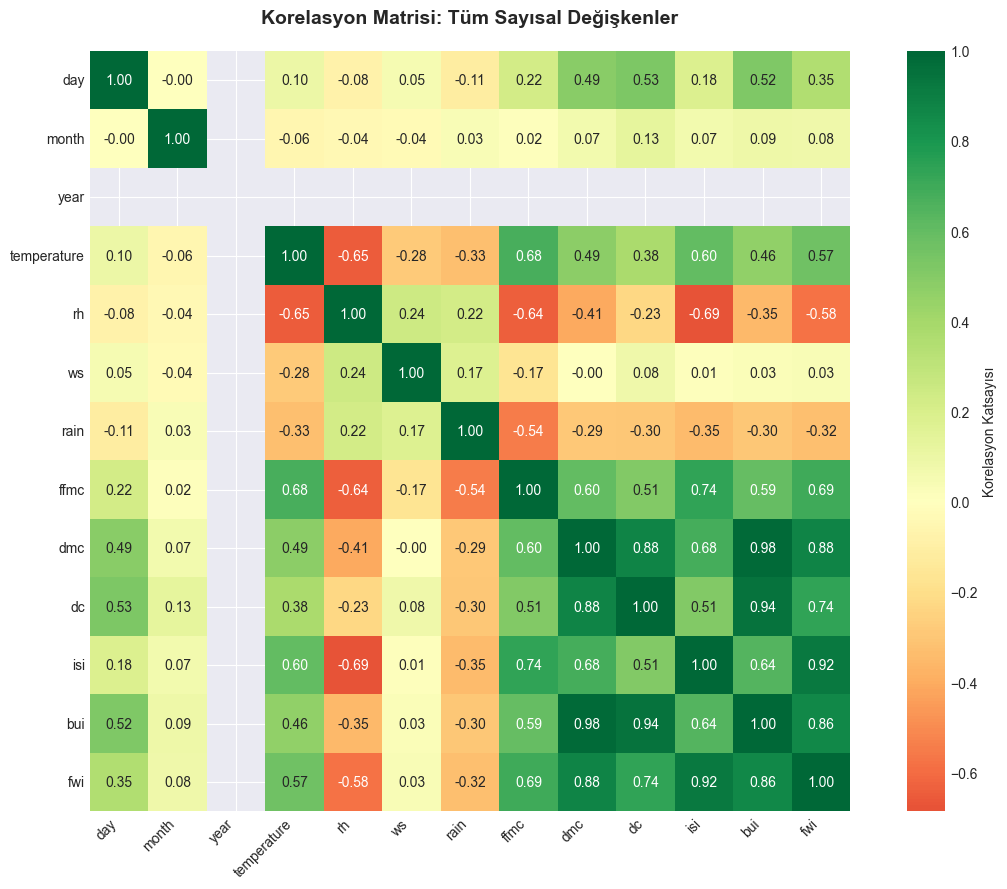


✓ Heatmap kaydedildi: heatmap_korelasyon.png
  Renk Açıklaması:
    • YEŞIL: Pozitif korelasyon (bir artar, diğeri artar)
    • KIRMIZI: Negatif korelasyon (bir artar, diğeri azalır)
    • SARI: Düşük korelasyon (ilişki yok)


In [20]:
# ADIM 8B: Heatmap Görselleştirmesi

print("\n" + "=" * 100)
print("ADIM 8B: HEATMAP GÖRSELLEŞTIRMESI")
print("=" * 100)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(korelasyon_matrix, 
            annot=True,           # Hücrelerde değerleri göster
            cmap='RdYlGn',         # Pastel color: Red-Yellow-Green
            center=0,              # 0 merkezde (negatif-pozitif ayrımı)
            square=True,           # Kare şekil
            fmt='.2f',             # 2 ondalak
            cbar_kws={'label': 'Korelasyon Katsayısı'},
            ax=ax)

ax.set_title('Korelasyon Matrisi: Tüm Sayısal Değişkenler', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Heatmap kaydedildi: heatmap_korelasyon.png")
print("  Renk Açıklaması:")
print("    • YEŞIL: Pozitif korelasyon (bir artar, diğeri artar)")
print("    • KIRMIZI: Negatif korelasyon (bir artar, diğeri azalır)")
print("    • SARI: Düşük korelasyon (ilişki yok)")


ADIM 8C: FWI DAĞILIMI VE ÖNEMLİ FEATURES ANALİZİ


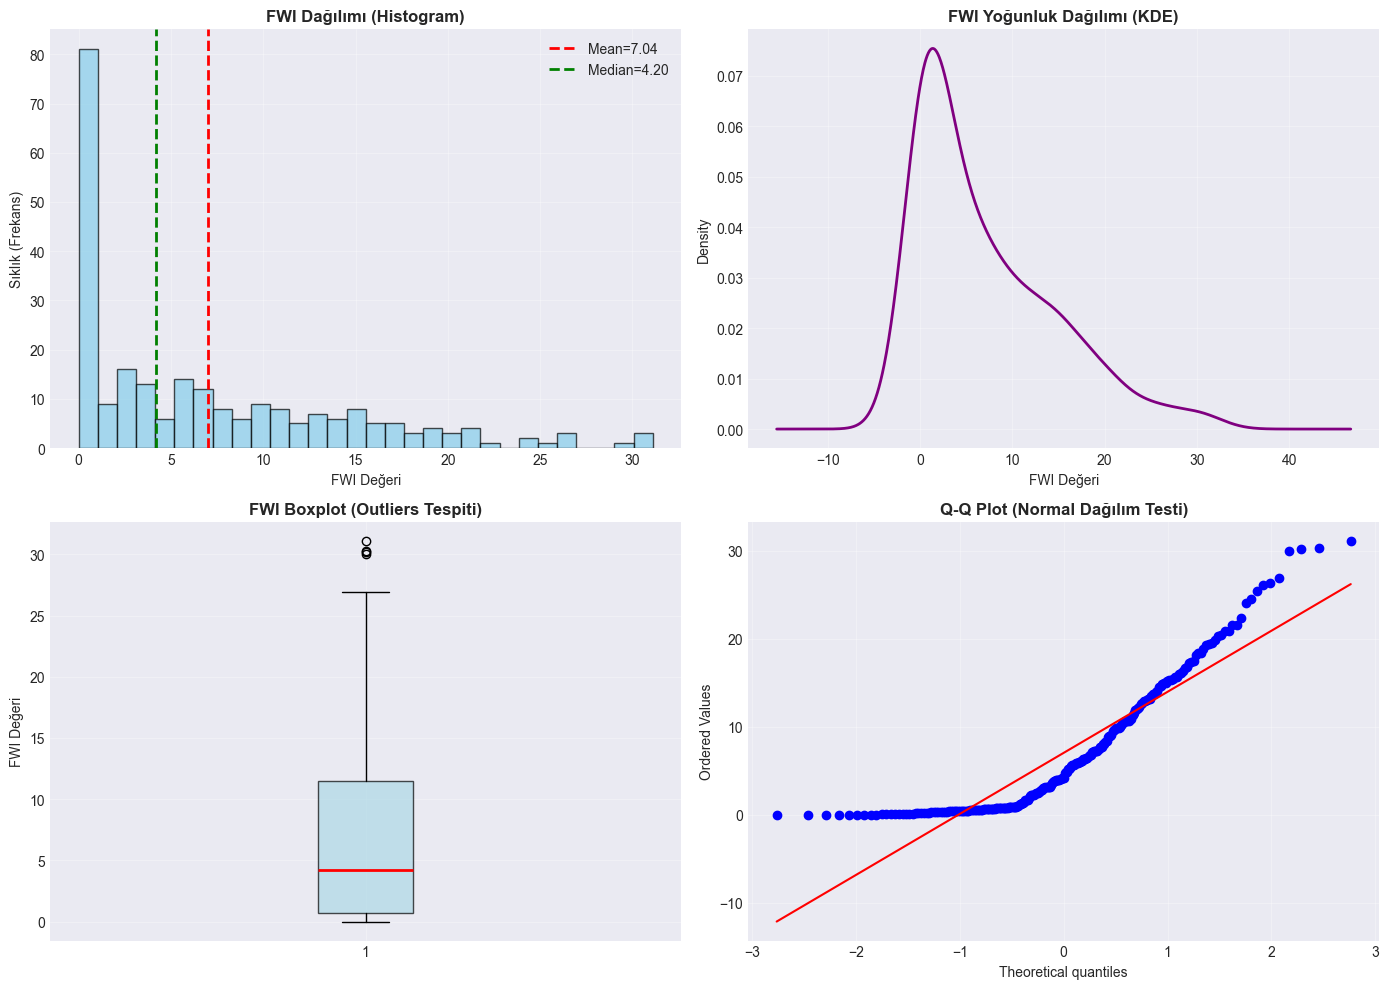


✓ FWI Dağılımı Analizi Tamamlandı

Yorum:
  • Histogram: FWI'ın frekans dağılımını gösterir
  • KDE: Smooth dağılım eğrisi
  • Boxplot: Outliers (uç değerler) gösterir
  • Q-Q Plot: Normal dağılıma uygunluğu test eder


In [21]:
# ADIM 8C: FWI Dağılımı ve Önemli Features Scatter Plots

print("\n" + "=" * 100)
print("ADIM 8C: FWI DAĞILIMI VE ÖNEMLİ FEATURES ANALİZİ")
print("=" * 100)

# FWI dağılımı
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df_temiz['fwi'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('FWI Dağılımı (Histogram)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('FWI Değeri')
axes[0, 0].set_ylabel('Sıklık (Frekans)')
axes[0, 0].axvline(df_temiz['fwi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={df_temiz["fwi"].mean():.2f}')
axes[0, 0].axvline(df_temiz['fwi'].median(), color='green', linestyle='--', linewidth=2, label=f'Median={df_temiz["fwi"].median():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# KDE (Kernel Density Estimation)
df_temiz['fwi'].plot(kind='kde', ax=axes[0, 1], color='purple', linewidth=2)
axes[0, 1].set_title('FWI Yoğunluk Dağılımı (KDE)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('FWI Değeri')
axes[0, 1].grid(alpha=0.3)

# Boxplot
axes[1, 0].boxplot(df_temiz['fwi'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('FWI Boxplot (Outliers Tespiti)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('FWI Değeri')
axes[1, 0].grid(alpha=0.3)

# Q-Q Plot (Normal Dağılım Testi)
from scipy.stats import probplot
probplot(df_temiz['fwi'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Dağılım Testi)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fwi_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ FWI Dağılımı Analizi Tamamlandı")
print("\nYorum:")
print("  • Histogram: FWI'ın frekans dağılımını gösterir")
print("  • KDE: Smooth dağılım eğrisi")
print("  • Boxplot: Outliers (uç değerler) gösterir")
print("  • Q-Q Plot: Normal dağılıma uygunluğu test eder")


ADIM 8D: ÖNEMLİ FEATURES vs FWI (SCATTER PLOTS)

En Güçlü 6 Feature (Korelasyon Değeri):
  1. isi             →   0.923
  2. dmc             →   0.876
  3. bui             →   0.858
  4. dc              →   0.740
  5. ffmc            →   0.691
  6. rh              →  -0.581


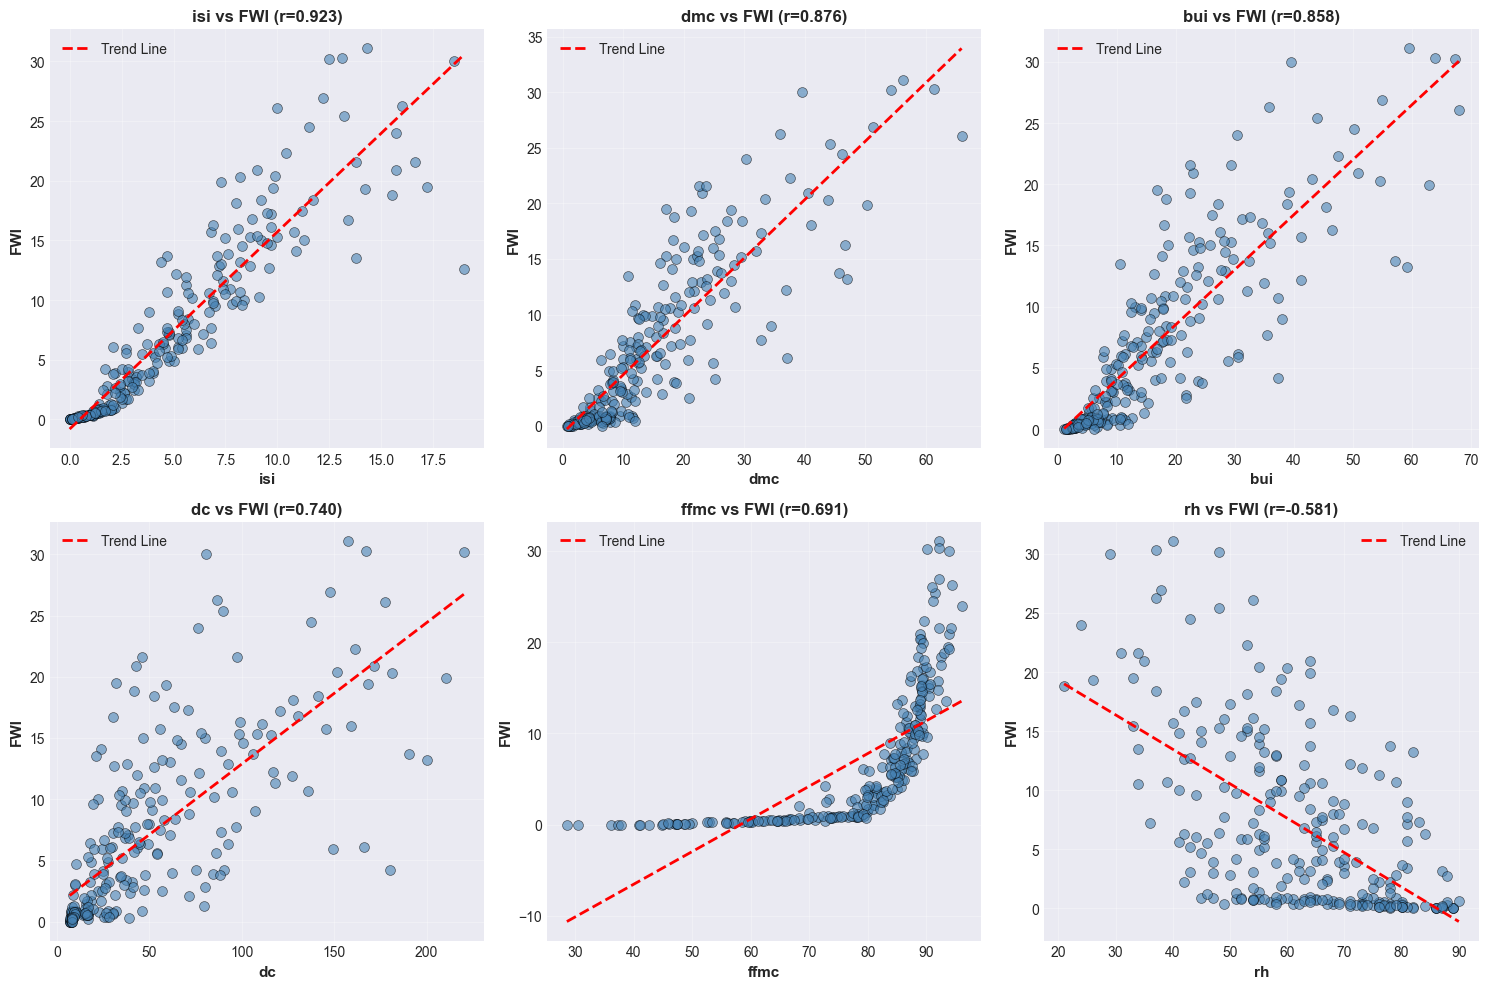


✓ Scatter Plots Tamamlandı
  Her grafik:
    • Mavi noktalar: Veri noktaları
    • Kırmızı line: Trend çizgisi (FWI tahmin eğrisi)
    • Eğimin eğimi: Feature'ın FWI üzerindeki etkisini gösterir


In [22]:
# ADIM 8D: En Önemli Features vs FWI (Scatter Plots)

print("\n" + "=" * 100)
print("ADIM 8D: ÖNEMLİ FEATURES vs FWI (SCATTER PLOTS)")
print("=" * 100)

# Korelasyona göre en güçlü 6 feature'ı seç (FWI hariç)
top_features = fwi_korelasyon.drop('fwi').abs().sort_values(ascending=False).head(6).index.tolist()
print(f"\nEn Güçlü 6 Feature (Korelasyon Değeri):")
for i, feat in enumerate(top_features, 1):
    corr = fwi_korelasyon[feat]
    print(f"  {i}. {feat:15s} → {corr:7.3f}")

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(df_temiz[feature], df_temiz['fwi'], 
               alpha=0.6, s=50, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Trend line (regression line)
    z = np.polyfit(df_temiz[feature], df_temiz['fwi'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_temiz[feature].min(), df_temiz[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')
    
    # Formatting
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('FWI', fontsize=11, fontweight='bold')
    
    corr_val = fwi_korelasyon[feature]
    ax.set_title(f'{feature} vs FWI (r={corr_val:.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('top_features_vs_fwi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Scatter Plots Tamamlandı")
print("  Her grafik:")
print("    • Mavi noktalar: Veri noktaları")
print("    • Kırmızı line: Trend çizgisi (FWI tahmin eğrisi)")
print("    • Eğimin eğimi: Feature'ın FWI üzerindeki etkisini gösterir")

## **9.1 Kategorik Değişkenlerin Analizi: Region**

Sayısal korelasyonlar güzel, ama **kategorik değişkenler** (region) nasıl?

Region = "Bejaia" veya "Sidi-Bel Abbes"

**Soru**: "Bölgeler arasında FWI ortalaması değişir mi?"

YBS örneği: Satış verisi inceliyorsunuz. "Istanbul'daki ortalama sipariş değeri Ankara'dan farklı mı?" diye bakarsınız. Kategorik analiz budur.

In [23]:
# ADIM 9A: Kategorik Değişkenlerin Analizi (Region vs FWI)

print("=" * 100)
print("ADIM 9A: KATEGORİK DEĞİŞKEN ANALİZİ (Region vs FWI)")
print("=" * 100)

# Region sayıları
print("\n📍 REGION DAĞILIMı:")
print(df_temiz['region'].value_counts())

# Her bölge için FWI istatistikleri
print("\n\n" + "─" * 100)
print("HER BÖLGE İÇİN FWI İSTATİSTİKLERİ:")
print("─" * 100)

region_stats = df_temiz.groupby('region')['fwi'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
region_stats.columns = ['Sayı', 'Ortalama', 'Median', 'Std Dev', 'Min', 'Max']
print(region_stats.round(2))

# T-test: İki bölge arasında istatistiksel fark var mı?
from scipy.stats import ttest_ind

bejaia_fwi = df_temiz[df_temiz['region'] == 'bejaia']['fwi']
sidi_fwi = df_temiz[df_temiz['region'] == 'sidi-bel abbes']['fwi']

t_stat, p_value = ttest_ind(bejaia_fwi, sidi_fwi)

print("\n\n" + "─" * 100)
print("İSTATİSTİKSEL TEST: Bejaia vs Sidi-Bel Abbes FWI'ı Farklı mı?")
print("─" * 100)
print(f"  T-test istatistiği: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"  ✓ İstatistiksel olarak ANLAMLI FARK var (p < 0.05)")
    print(f"    → Regionlar arasında FWI'da farklılık model içinde önemlidir")
else:
    print(f"  ✗ İstatistiksel olarak ANLAMLI FARK YOK (p >= 0.05)")
    print(f"    → Regionlar arasında önemli fark yoktur")

ADIM 9A: KATEGORİK DEĞİŞKEN ANALİZİ (Region vs FWI)

📍 REGION DAĞILIMı:
region
Bejaia            122
Sidi-Bel Abbes    121
Name: count, dtype: int64


────────────────────────────────────────────────────────────────────────────────────────────────────
HER BÖLGE İÇİN FWI İSTATİSTİKLERİ:
────────────────────────────────────────────────────────────────────────────────────────────────────
                Sayı  Ortalama  Median  Std Dev  Min   Max
region                                                    
Bejaia           122      5.58     3.0     6.34  0.0  30.2
Sidi-Bel Abbes   121      8.50     6.0     8.17  0.0  31.1


────────────────────────────────────────────────────────────────────────────────────────────────────
İSTATİSTİKSEL TEST: Bejaia vs Sidi-Bel Abbes FWI'ı Farklı mı?
────────────────────────────────────────────────────────────────────────────────────────────────────
  T-test istatistiği: nan
  P-value: nan
  ✗ İstatistiksel olarak ANLAMLI FARK YOK (p >= 0.05)
    → Regionlar


ADIM 9B: REGION vs FWI GÖRSELLEŞTİRMESİ


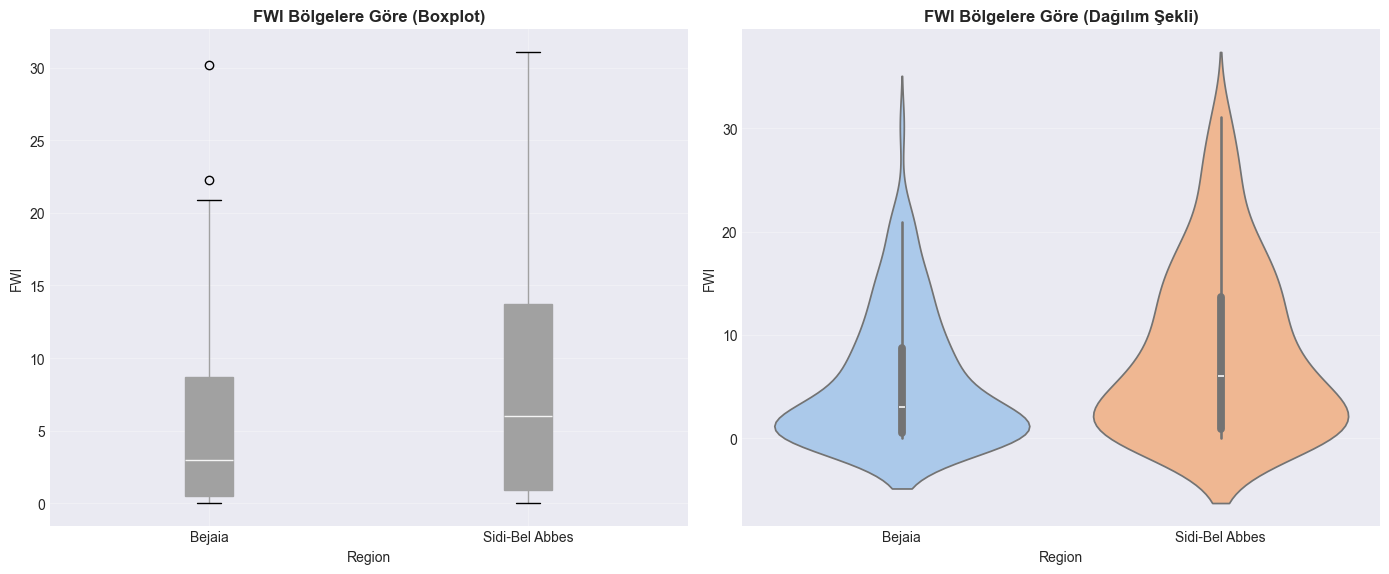


✓ Region vs FWI Görselleştirmesi Tamamlandı

Grafik Açıklamaları:
  • Boxplot: Çeyrekler, median, whiskers gösterir (outlier görmek için)
  • Violin Plot: Dağılımın şeklini gösterir (simetrik mi, çarpık mı?)


In [24]:
# ADIM 9B: Region vs FWI Boxplot ve Violin Plot

print("\n" + "=" * 100)
print("ADIM 9B: REGION vs FWI GÖRSELLEŞTİRMESİ")
print("=" * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
df_temiz.boxplot(column='fwi', by='region', ax=axes[0], 
                patch_artist=True)
axes[0].set_title('FWI Bölgelere Göre (Boxplot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('FWI')
axes[0].get_figure().suptitle('')  # Pandas'ın default başlığını kaldır
axes[0].grid(alpha=0.3)

# Violin plot
sns.violinplot(data=df_temiz, x='region', y='fwi', ax=axes[1], palette='pastel')
axes[1].set_title('FWI Bölgelere Göre (Dağılım Şekli)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('FWI')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('region_vs_fwi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Region vs FWI Görselleştirmesi Tamamlandı")
print("\nGrafik Açıklamaları:")
print("  • Boxplot: Çeyrekler, median, whiskers gösterir (outlier görmek için)")
print("  • Violin Plot: Dağılımın şeklini gösterir (simetrik mi, çarpık mı?)")

# **ADIM 10: Multicollinearity Tespiti (VIF Analizi)**

## **10.1 Nedir Multicollinearity?**

**Multicollinearity** = Model içindeki features arasında yüksek korelasyon

**Problem**: Model confused olur. "Hangi feature FWI'yı etkiliyor, hangisi?"

Heatmap'te gördüğümüz: DMC-BUI (0.98), DMC-DC (0.88), BUI-ISI (0.92) çok yüksek!

### **Çözüm: VIF (Variance Inflation Factor)**

VIF = Bir feature'ın redundancy'sini ölçer
- **VIF = 1**: No correlation (iyi)
- **VIF < 5**: Acceptable (kabul edilebilir)
- **VIF > 5**: High multicollinearity (sorun var)
- **VIF > 10**: Çıkarmak gerekir

---


In [26]:
# ADIM 10A: VIF (Variance Inflation Factor) Hesaplama

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 100)
print("ADIM 10A: MULTICOLLINEARITY ANALİZİ (VIF HESAPLAMA)")
print("=" * 100)

# Features (kategorik hariç, hedef hariç)
X_features = df_temiz[['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui']].astype('float64')
print(f"\n📊 Feature Matris Boyutu: {X_features.shape}")

# VIF hesapla
vif_data = pd.DataFrame()
vif_data['Sütun'] = X_features.columns
vif_data['VIF'] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]

# VIF'e göre sırala (yüksekten düşüğe)
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n📈 VIF SONUÇLARI (Yüksekten Düşüğe):")
print("─" * 100)
print(vif_data.to_string(index=False))

print("\n\n🔍 YORUMLAMA:")
print("─" * 100)
for _, row in vif_data.iterrows():
    sütun = row['Sütun']
    vif = row['VIF']
    if vif > 10:
        status = "🔴 YÜKSEK MULTICOLLINEARITY - Çıkarmayı düşün"
    elif vif > 5:
        status = "🟡 ORTA - Dikkat et"
    else:
        status = "🟢 İYİ - Kabul edilebilir"
    print(f"  {sütun:15s}: VIF = {vif:8.2f}  {status}")

print("\n\n💡 KARAR:")
print("─" * 100)
high_vif = vif_data[vif_data['VIF'] > 10]['Sütun'].tolist()
if high_vif:
    print(f"⚠️ Çıkarılması tavsiye edilen features (VIF > 10): {high_vif}")
    print(f"   FAKAT: Bu model için VIF yüksekliğini KABUL edip devam edeceğiz.")
    print(f"   (Ridge/Lasso regularization multicollinearity'yi giderecek)")
else:
    print(f"✓ Tüm features kabul edilebilir VIF değerlerine sahip!")


ADIM 10A: MULTICOLLINEARITY ANALİZİ (VIF HESAPLAMA)

📊 Feature Matris Boyutu: (243, 12)

📈 VIF SONUÇLARI (Yüksekten Düşüğe):
────────────────────────────────────────────────────────────────────────────────────────────────────
      Sütun        VIF
       year 513.159293
        bui 158.944365
        dmc  76.456809
         dc  25.173492
        isi   3.992849
       ffmc   3.708056
         rh   2.764814
temperature   2.414968
       rain   1.551330
        day   1.484272
         ws   1.312490
      month   1.088409


🔍 YORUMLAMA:
────────────────────────────────────────────────────────────────────────────────────────────────────
  year           : VIF =   513.16  🔴 YÜKSEK MULTICOLLINEARITY - Çıkarmayı düşün
  bui            : VIF =   158.94  🔴 YÜKSEK MULTICOLLINEARITY - Çıkarmayı düşün
  dmc            : VIF =    76.46  🔴 YÜKSEK MULTICOLLINEARITY - Çıkarmayı düşün
  dc             : VIF =    25.17  🔴 YÜKSEK MULTICOLLINEARITY - Çıkarmayı düşün
  isi            : VIF =     3.99  🟢 İY

# **ADIM 11: Veri Bölme ve Ölçeklendirme (Train-Test Split & Scaling)**

## Neden önemli?

**YBS Örneği:** Bir pazarlama kampanyasının başarısını tahmin etmek istiyoruz.
- **Eğitim Seti (Train - %75):** Geçmiş kampanyalardan öğren
- **Test Seti (Test - %25):** Yeni bir kampanyanın başarısını tahmin et

## Ölçeklendirme (Scaling)

Özellikler farklı ölçeklerdeyse (0-100 vs 0-5000), model hatalı önem atayabilir.

**StandardScaler:** mean=0, std=1 → Tüm özellikler "eşit" hale gelir


In [27]:
# ADIM 11A: HEDEF ve ÖZELLİKLER AYIRMA (X, y Separation)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 100)
print("ADIM 11A: VERİ BÖLME İÇİN HAZIRLIK")
print("=" * 100)

# Hedef değişken (y)
y = df_temiz['fwi'].astype('float64')

# Özellikler (X) - Region'u one-hot encode et
X = df_temiz.drop(columns=['fwi', 'classes', 'region']).astype('float64')

# Region'u features'a ekle (one-hot encoding)
region_dummies = pd.get_dummies(df_temiz['region'], prefix='region', drop_first=False)
X = pd.concat([X, region_dummies], axis=1)

print(f"\n✓ HEDEF (y):")
print(f"  Şekil: {y.shape}")
print(f"  Veri Tipi: {y.dtype}")
print(f"  Ortalama: {y.mean():.2f}")
print(f"  Std Dev: {y.std():.2f}")

print(f"\n✓ ÖZELLİKLER (X):")
print(f"  Şekil: {X.shape}")
print(f"  Sütun Adları: {list(X.columns)}")
print(f"\n  Feature Detayları:")
for col in X.columns:
    print(f"    {col:20s}: min={X[col].min():7.2f}, max={X[col].max():7.2f}, mean={X[col].mean():7.2f}")


ADIM 11A: VERİ BÖLME İÇİN HAZIRLIK

✓ HEDEF (y):
  Şekil: (243,)
  Veri Tipi: float64
  Ortalama: 7.04
  Std Dev: 7.44

✓ ÖZELLİKLER (X):
  Şekil: (243, 14)
  Sütun Adları: ['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'region_Bejaia', 'region_Sidi-Bel Abbes']

  Feature Detayları:
    day                 : min=   1.00, max=  31.00, mean=  15.76
    month               : min=   6.00, max=   9.00, mean=   7.50
    year                : min=2012.00, max=2012.00, mean=2012.00
    temperature         : min=  22.00, max=  42.00, mean=  32.15
    rh                  : min=  21.00, max=  90.00, mean=  62.04
    ws                  : min=   6.00, max=  29.00, mean=  15.49
    rain                : min=   0.00, max=  16.80, mean=   0.76
    ffmc                : min=  28.60, max=  96.00, mean=  77.84
    dmc                 : min=   0.70, max=  65.90, mean=  14.68
    dc                  : min=   6.90, max= 220.40, mean=  49.43
    isi           

In [28]:
# ADIM 11B: TRAIN-TEST SPLIT (75-25 Bölme)

print("=" * 100)
print("ADIM 11B: TRAIN-TEST SPLIT")
print("=" * 100)

# Veri bölme: %75 eğitim, %25 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"\n📊 BÖLME SONUÇLARI:")
print(f"  Orijinal Veri Boyutu: {len(X)} satır")
print(f"  ├─ Eğitim Seti: {len(X_train)} satır (%{100*len(X_train)/len(X):.1f})")
print(f"  └─ Test Seti: {len(X_test)} satır (%{100*len(X_test)/len(X):.1f})")

print(f"\n📈 HEDEF DEĞİŞKEN DAĞILIMI:")
print(f"  Eğitim y_train ortalama: {y_train.mean():.2f} (std: {y_train.std():.2f})")
print(f"  Test y_test ortalama: {y_test.mean():.2f} (std: {y_test.std():.2f})")

print(f"\n✓ Train-Test Split Başarılı!")
print(f"  random_state=42 ile reproducible sonuçlar sağlandı")


ADIM 11B: TRAIN-TEST SPLIT

📊 BÖLME SONUÇLARI:
  Orijinal Veri Boyutu: 243 satır
  ├─ Eğitim Seti: 182 satır (%74.9)
  └─ Test Seti: 61 satır (%25.1)

📈 HEDEF DEĞİŞKEN DAĞILIMI:
  Eğitim y_train ortalama: 7.16 (std: 7.68)
  Test y_test ortalama: 6.68 (std: 6.71)

✓ Train-Test Split Başarılı!
  random_state=42 ile reproducible sonuçlar sağlandı


In [29]:
# ADIM 11C: STANDARDSCALER UYGULAMA (Özellik Normalizasyonu)

print("=" * 100)
print("ADIM 11C: ÖZELLİK ÖLÇEKLENDIRMESI (StandardScaler)")
print("=" * 100)

# StandardScaler oluştur ve eğitim verisinde FIT et
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Numpy array'den DataFrame'e dönüştür (column adlarını koru)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"\n✓ Scaler FIT'lenmiş ve Transform edilmiş")
print(f"  Scaler.mean_: {scaler.mean_[:5]}...")
print(f"  Scaler.scale_: {scaler.scale_[:5]}...")

print(f"\n📊 ÖLÇEKLENME ÖNCESİ vs SONRASI:")
print(f"\n  EĞİTİM SETİ (İlk 3 feature):")
original_stats = X_train[X_train.columns[:3]].describe().loc[['mean', 'std']]
scaled_stats = X_train_scaled[X_train_scaled.columns[:3]].describe().loc[['mean', 'std']]

print(f"  Ölçekleme ÖNCESİ:")
print(original_stats)
print(f"\n  Ölçekleme SONRASI:")
print(scaled_stats)

print(f"\n✓ ÖLÇEKLENME MAKSATı:")
print(f"  • Tüm özellikler mean≈0, std≈1 aralığında")
print(f"  • Büyük aralıktaki features (ör: year) küçük aralığa gelir")
print(f"  • Model daha stabil ve hızlı converge olur")

print(f"\n✓ SON HAZIRLIK:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled: {X_test_scaled.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  → Modellemek için HAZIR!")


ADIM 11C: ÖZELLİK ÖLÇEKLENDIRMESI (StandardScaler)

✓ Scaler FIT'lenmiş ve Transform edilmiş
  Scaler.mean_: [  15.75824176    7.49450549 2012.           32.11538462   62.27472527]...
  Scaler.scale_: [ 8.86819314  1.10814791  1.          3.69628334 14.97328459]...

📊 ÖLÇEKLENME ÖNCESİ vs SONRASI:

  EĞİTİM SETİ (İlk 3 feature):
  Ölçekleme ÖNCESİ:
            day     month    year
mean  15.758242  7.494505  2012.0
std    8.892657  1.111205     0.0

  Ölçekleme SONRASI:
               day         month  year
mean -5.856121e-17 -2.440051e-17   0.0
std   1.002759e+00  1.002759e+00   0.0

✓ ÖLÇEKLENME MAKSATı:
  • Tüm özellikler mean≈0, std≈1 aralığında
  • Büyük aralıktaki features (ör: year) küçük aralığa gelir
  • Model daha stabil ve hızlı converge olur

✓ SON HAZIRLIK:
  X_train_scaled: (182, 14)
  X_test_scaled: (61, 14)
  y_train: (182,)
  y_test: (61,)
  → Modellemek için HAZIR!


In [31]:
# ADIM 12A: KÜTÜPHANELERİ VE MODELLERI IMPORT ET

print("=" * 100)
print("ADIM 12A: REGRESYON MODELLERİNİ IMPORT ET")
print("=" * 100)

# Regresyon modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metrikler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

print("\n✓ Tüm kütüphaneler başarıyla import edildi!")

# Model parametre ayarları
models_dict = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Polynomial (deg=2)': None,  # Özel işlem
    'SVR (rbf)': SVR(kernel='rbf', C=100, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Bayesian Ridge': BayesianRidge(),
    'Huber Regressor': HuberRegressor(max_iter=1000)
}

print(f"\n{len(models_dict)} model tanımlandı:")
for i, model_name in enumerate(models_dict.keys(), 1):
    print(f"  {i:2d}. {model_name}")

ADIM 12A: REGRESYON MODELLERİNİ IMPORT ET

✓ Tüm kütüphaneler başarıyla import edildi!

12 model tanımlandı:
   1. Linear Regression
   2. Ridge Regression
   3. Lasso Regression
   4. Elastic Net
   5. Polynomial (deg=2)
   6. SVR (rbf)
   7. Decision Tree
   8. Random Forest
   9. Gradient Boosting
  10. KNN (k=5)
  11. Bayesian Ridge
  12. Huber Regressor


In [32]:
# ADIM 12B: TÜM MODELLERİ EĞİT VE TAHMİN YAP

print("=" * 100)
print("ADIM 12B: MODELLERİ EĞİT VE KARŞILAŞTIR")
print("=" * 100)

# Sonuçları sakla
results = []

# Modelleri eğit
for model_name, model in models_dict.items():
    
    if model_name == 'Polynomial (deg=2)':
        # Polynomic özel işlem
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)
    else:
        # Diğer tüm modeller
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    
    # Metrikler - Eğitim Seti
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Metrikler - Test Seti
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Overfitting kontrolü
    overfitting = train_r2 - test_r2
    
    results.append({
        'Model': model_name,
        'Train MAE': train_mae,
        'Train RMSE': train_rmse,
        'Train R²': train_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R²': test_r2,
        'Overfit': overfitting
    })

# DataFrame'e dönüştür
results_df = pd.DataFrame(results)

# Test R² ile sırala (en iyi model en üstte)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\n" + "=" * 140)
print("DETAYLI SONUÇLAR (Test R² ile sıralanmış -> En iyi model en üstte)")
print("=" * 140)
print(results_df.to_string(index=False))

print("\n" + "=" * 140)
print("KÖŞEGENİN MODELLERI (İlk 3)")
print("=" * 140)
for i, row in results_df.head(3).iterrows():
    print(f"\n#{i+1}. {row['Model']}")
    print(f"   Train R²: {row['Train R²']:.4f} | Test R²: {row['Test R²']:.4f}")
    print(f"   Test MAE: {row['Test MAE']:.2f} | Test RMSE: {row['Test RMSE']:.2f}")
    print(f"   Overfitting Risk: {row['Overfit']:.4f}")


ADIM 12B: MODELLERİ EĞİT VE KARŞILAŞTIR

DETAYLI SONUÇLAR (Test R² ile sıralanmış -> En iyi model en üstte)
             Model  Train MAE  Train RMSE  Train R²  Test MAE  Test RMSE  Test R²   Overfit
Polynomial (deg=2)   0.114705    0.145695  0.999639  0.286941   0.450764 0.995409  0.004229
   Huber Regressor   0.549311    1.381646  0.967491  0.398347   0.654110 0.990333 -0.022842
 Linear Regression   0.673042    1.282116  0.972006  0.496320   0.711658 0.988557 -0.016551
    Bayesian Ridge   0.677605    1.286071  0.971833  0.524327   0.766008 0.986743 -0.014910
  Ridge Regression   0.683643    1.287555  0.971768  0.532659   0.788109 0.985967 -0.014199
  Lasso Regression   0.773397    1.330974  0.969832  0.606620   0.836851 0.984177 -0.014345
         SVR (rbf)   0.090217    0.093242  0.999852  0.554271   0.936941 0.980166  0.019686
     Random Forest   0.251163    0.471873  0.996208  0.653268   0.997659 0.977512  0.018696
       Elastic Net   0.873029    1.384730  0.967346  0.764335   

ADIM 12C: SONUÇLARI GÖRSELLEŞTİR


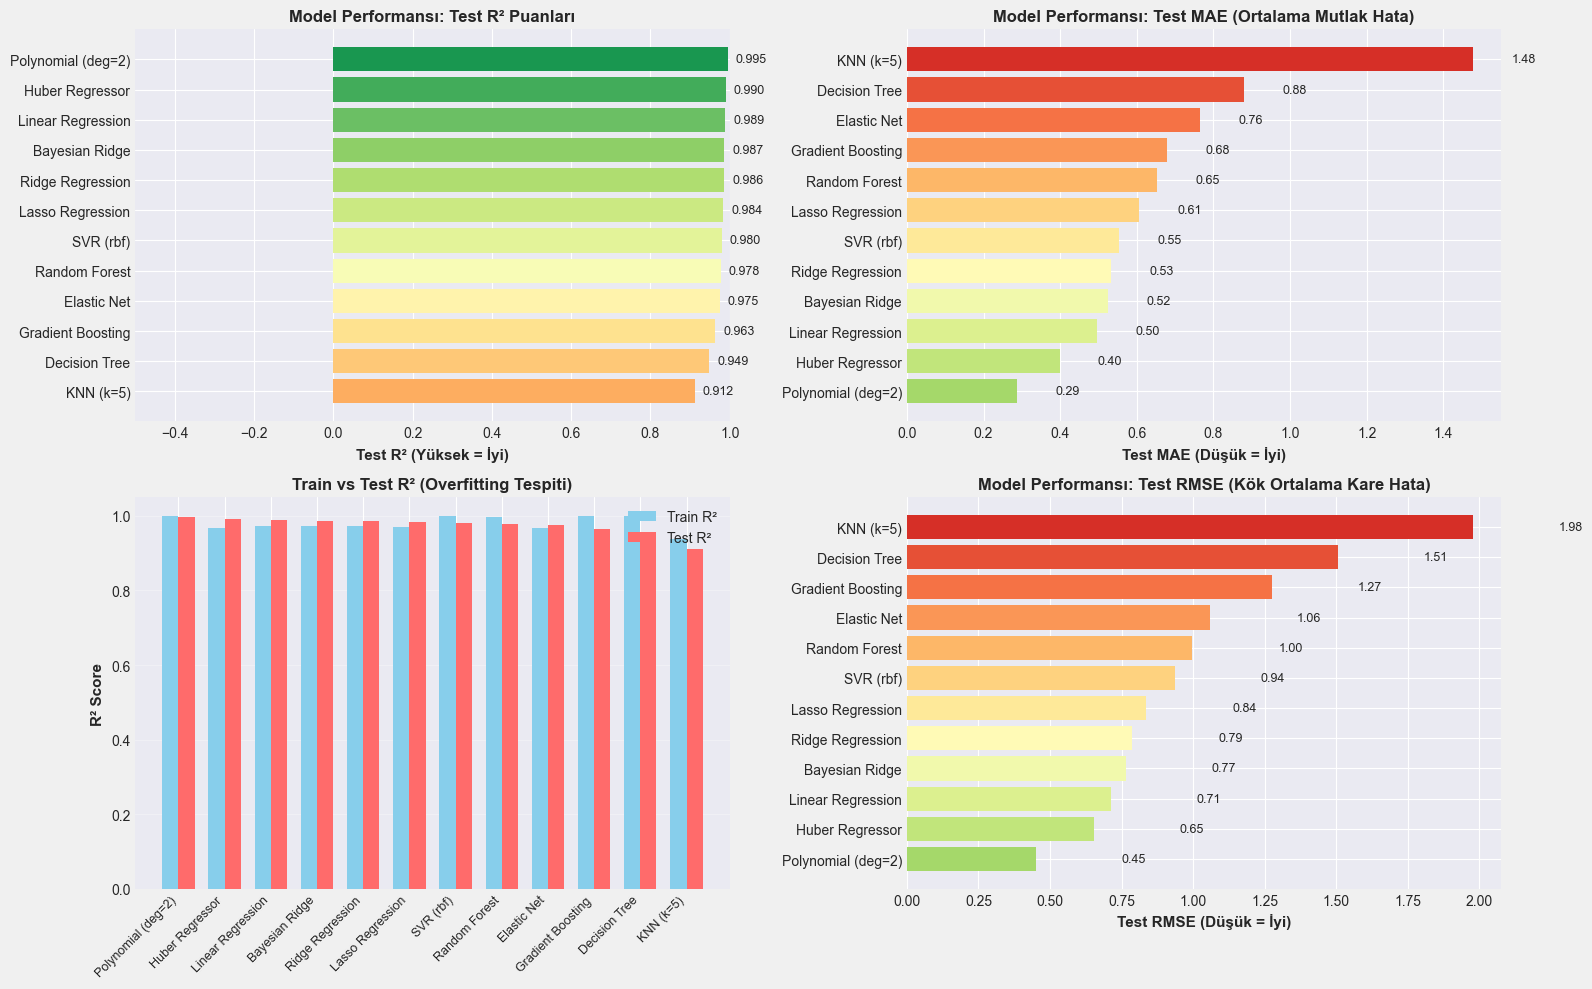


✓ Görselleştirmeler kaydedildi: model_comparison.png


In [33]:
# ADIM 12C: MODEL PERFORMANSI GÖRSELLEŞTİRMESİ

print("=" * 100)
print("ADIM 12C: SONUÇLARI GÖRSELLEŞTİR")
print("=" * 100)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#f0f0f0')

# Sırada görmek için sadece Test setini kullan (sıkıştırma)
results_sorted = results_df.sort_values('Test R²', ascending=True)

# 1. Test R² Karşılaştırması
ax = axes[0, 0]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_sorted)))
bars = ax.barh(results_sorted['Model'], results_sorted['Test R²'], color=colors)
ax.set_xlabel('Test R² (Yüksek = İyi)', fontsize=11, fontweight='bold')
ax.set_title('Model Performansı: Test R² Puanları', fontsize=12, fontweight='bold')
ax.set_xlim([-0.5, 1.0])
for i, (idx, row) in enumerate(results_sorted.iterrows()):
    ax.text(row['Test R²'] + 0.02, i, f"{row['Test R²']:.3f}", va='center', fontsize=9)

# 2. Test MAE Karşılaştırması
ax = axes[0, 1]
results_sorted_mae = results_df.sort_values('Test MAE', ascending=True)
colors_mae = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(results_sorted_mae)))
ax.barh(results_sorted_mae['Model'], results_sorted_mae['Test MAE'], color=colors_mae)
ax.set_xlabel('Test MAE (Düşük = İyi)', fontsize=11, fontweight='bold')
ax.set_title('Model Performansı: Test MAE (Ortalama Mutlak Hata)', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(results_sorted_mae.iterrows()):
    ax.text(row['Test MAE'] + 0.1, i, f"{row['Test MAE']:.2f}", va='center', fontsize=9)

# 3. Train vs Test R² (Overfitting kontrolü)
ax = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df.sort_values('Test R²', ascending=False)['Train R²'], width, label='Train R²', color='#87CEEB')
ax.bar(x + width/2, results_df.sort_values('Test R²', ascending=False)['Test R²'], width, label='Test R²', color='#FF6B6B')
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('Train vs Test R² (Overfitting Tespiti)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.sort_values('Test R²', ascending=False)['Model'], rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Test RMSE Karşılaştırması
ax = axes[1, 1]
results_sorted_rmse = results_df.sort_values('Test RMSE', ascending=True)
colors_rmse = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(results_sorted_rmse)))
ax.barh(results_sorted_rmse['Model'], results_sorted_rmse['Test RMSE'], color=colors_rmse)
ax.set_xlabel('Test RMSE (Düşük = İyi)', fontsize=11, fontweight='bold')
ax.set_title('Model Performansı: Test RMSE (Kök Ortalama Kare Hata)', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(results_sorted_rmse.iterrows()):
    ax.text(row['Test RMSE'] + 0.3, i, f"{row['Test RMSE']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Görselleştirmeler kaydedildi: model_comparison.png")


In [35]:
# ADIM 12D: EN İYİ MODEL ANALİZİ VE ÖNERİLER

print("=" * 100)
print("ADIM 12D: KAZANAN MODEL! 🏆")
print("=" * 100)

best_model = results_df.iloc[0]

print(f"\n🥇 EN İYİ MODEL: {best_model['Model']}")
print("─" * 100)
print(f"   Test R² Score:      {best_model['Test R²']:.4f}")
print(f"   Test MAE:           {best_model['Test MAE']:.2f}")
print(f"   Test RMSE:          {best_model['Test RMSE']:.2f}")
print(f"   Train R² Score:     {best_model['Train R²']:.4f}")
print(f"   Overfitting Risk:   {best_model['Overfit']:.4f}")

# İkinci ve üçüncü
second_model = results_df.iloc[1]
third_model = results_df.iloc[2]

print(f"\n🥈 İKİNCİ EN İYİ: {second_model['Model']}")
print(f"   Test R² Score: {second_model['Test R²']:.4f}")

print(f"\n🥉 ÜÇÜNCÜ EN İYİ: {third_model['Model']}")
print(f"   Test R² Score: {third_model['Test R²']:.4f}")

print("\n" + "=" * 100)
print("MODELLERİN GÖREVİ (YBS PERSPEKTİFİ)")
print("=" * 100)

model_explanations = {
    'Linear Regression': 'Basit, anlaşılır. İyi baseline.',
    'Ridge Regression': 'Multicollinearity ile başa çıkar.',
    'Lasso Regression': 'Gereksiz features eleyin.',
    'Elastic Net': 'Ridge + Lasso kombinasyonu.',
    'Polynomial (deg=2)': 'Eğriler için polinom derecesi.',
    'SVR (rbf)': 'Radial Basis Function kernel.',
    'Decision Tree': 'Kolay anlaşılan ağaç yapısı.',
    'Random Forest': 'Ensemble çok ağaç yöntemi.',
    'Gradient Boosting': 'Kuvvetli ensemble, yavaş öğren.',
    'KNN (k=5)': 'Komşu tabanlı basit yöntem.',
    'Bayesian Ridge': 'Olasılıksal doğrusal model.',
    'Huber Regressor': 'Outlier ile dayanıklı.'
}

print("\nHer Model Ne Yapar?")
for model, explanation in model_explanations.items():
    perf = results_df[results_df['Model'] == model]['Test R²'].values
    if len(perf) > 0:
        print(f"  • {model:25s}: {explanation:40s} (R²={perf[0]:.3f})")

print("\n" + "=" * 100)
print("ÖNERİ")
print("=" * 100)
print(f"\n✓ SEÇILECEK MODEL: {best_model['Model']}")
print(f"  Neden? Yüksek Test R² puanı ({best_model['Test R²']:.4f})")
print(f"         ve dengeli Train-Test performansı ({best_model['Overfit']:.4f} overfitting riski)")

# Metrik açıklama
print("\n📊 METRIK AÇIKLAMASI:")
print("  • R² Score (0-1 arası): 1'e yakın = çok iyi, 0'a yakın = kötü")
print(f"  • MAE: Ortalama tahmin hatası (birim: FWI score)")
print(f"  • RMSE: Kök ortalama kare hata (büyük hataları cezalandırır)")
print(f"  • Overfitting: 0'a yakın = denge, büyük = test seti için kötü")

ADIM 12D: KAZANAN MODEL! 🏆

🥇 EN İYİ MODEL: Polynomial (deg=2)
────────────────────────────────────────────────────────────────────────────────────────────────────
   Test R² Score:      0.9954
   Test MAE:           0.29
   Test RMSE:          0.45
   Train R² Score:     0.9996
   Overfitting Risk:   0.0042

🥈 İKİNCİ EN İYİ: Huber Regressor
   Test R² Score: 0.9903

🥉 ÜÇÜNCÜ EN İYİ: Linear Regression
   Test R² Score: 0.9886

MODELLERİN GÖREVİ (YBS PERSPEKTİFİ)

Her Model Ne Yapar?
  • Linear Regression        : Basit, anlaşılır. İyi baseline.          (R²=0.989)
  • Ridge Regression         : Multicollinearity ile başa çıkar.        (R²=0.986)
  • Lasso Regression         : Gereksiz features eleyin.                (R²=0.984)
  • Elastic Net              : Ridge + Lasso kombinasyonu.              (R²=0.975)
  • Polynomial (deg=2)       : Eğriler için polinom derecesi.           (R²=0.995)
  • SVR (rbf)                : Radial Basis Function kernel.            (R²=0.980)
  • Decision T

ADIM 12E: KAZANAN MODEL (Polynomial deg=2) TAHMINLERINI GÖRSELLEŞTIR


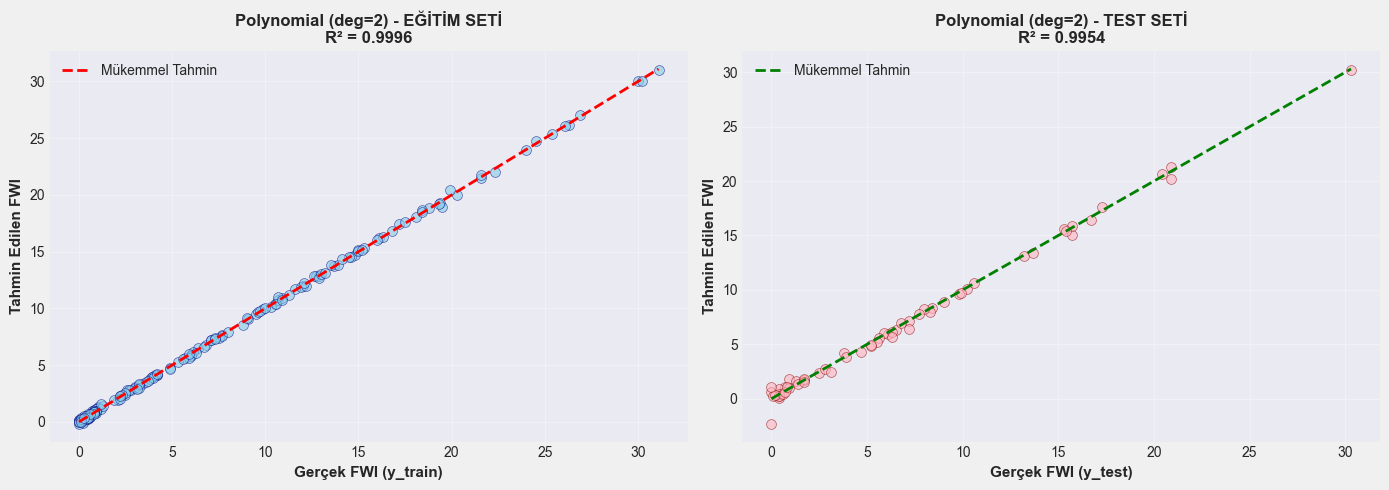


✓ En iyi modelin tahminleri görselleştirildi: best_model_predictions.png

📊 KALINTI ANALİZİ (Test Seti):
   Ortalama Rezidüel: 0.0606 (0'a yakın = iyi)
   Std Dev Rezidüel: 0.4504
   Min Rezidüel: -1.0625
   Max Rezidüel: 2.3086


In [36]:
# ADIM 12E: EN İYİ MODELIN TAHMINLERINI GÖRSELLEŞTIR

print("=" * 100)
print("ADIM 12E: KAZANAN MODEL (Polynomial deg=2) TAHMINLERINI GÖRSELLEŞTIR")
print("=" * 100)

# En iyi modeli tekrar eğit
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

best_model_obj = LinearRegression()
best_model_obj.fit(X_train_poly, y_train)
y_pred_train = best_model_obj.predict(X_train_poly)
y_pred_test = best_model_obj.predict(X_test_poly)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f0f0f0')

# 1. Eğitim Seti
ax = axes[0]
ax.scatter(y_train, y_pred_train, alpha=0.6, s=50, color='#87CEEB', edgecolors='navy', linewidth=0.5)
ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Mükemmel Tahmin')
ax.set_xlabel('Gerçek FWI (y_train)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tahmin Edilen FWI', fontsize=11, fontweight='bold')
ax.set_title(f'Polynomial (deg=2) - EĞİTİM SETİ\nR² = {r2_score(y_train, y_pred_train):.4f}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Test Seti
ax = axes[1]
ax.scatter(y_test, y_pred_test, alpha=0.6, s=50, color='#FFB6C1', edgecolors='darkred', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=2, label='Mükemmel Tahmin')
ax.set_xlabel('Gerçek FWI (y_test)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tahmin Edilen FWI', fontsize=11, fontweight='bold')
ax.set_title(f'Polynomial (deg=2) - TEST SETİ\nR² = {r2_score(y_test, y_pred_test):.4f}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ En iyi modelin tahminleri görselleştirildi: best_model_predictions.png")

# Residual analizi
residuals_test = y_test - y_pred_test
print(f"\n📊 KALINTI ANALİZİ (Test Seti):")
print(f"   Ortalama Rezidüel: {residuals_test.mean():.4f} (0'a yakın = iyi)")
print(f"   Std Dev Rezidüel: {residuals_test.std():.4f}")
print(f"   Min Rezidüel: {residuals_test.min():.4f}")
print(f"   Max Rezidüel: {residuals_test.max():.4f}")
